In [1]:
import jax
import jax.numpy as jnp
from jax import random
import numpyro
import numpyro.distributions as dist
from numpyro import plate
from numpyro.distributions import constraints

/home/dzhao268/anaconda3/envs/jax_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import numpy as np
from itertools import product, accumulate
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
import umap  
from functools import reduce
from tqdm import trange

In [3]:
import jax
import jax.numpy as jnp
from jax import random

def select_most_diverse(samples: jnp.ndarray, num_select: int = 3):
    """
    samples: (N, D)
    returns: python list of selected indices
    """
    N = samples.shape[0]
    selected = [0]

    # pairwise Euclidean distances
    diff = samples[:, None, :] - samples[None, :, :]   # (N, N, D)
    dist_matrix = jnp.linalg.norm(diff, axis=-1)      # (N, N)

    for _ in range(num_select - 1):
        dist_to_selected = dist_matrix[jnp.array(selected), :]  # (len(selected), N)
        min_dist = dist_to_selected.min(axis=0)                # (N,)

        # Set already selected indices to -1 so they won't be picked
        min_dist = min_dist.at[jnp.array(selected)].set(-1.0)
        next_idx = int(jnp.argmax(min_dist))
        selected.append(next_idx)

    return selected

def generate_distinct_distributions(key, N, V, concent=0.8):
    """
    Draw N samples from Dirichlet(alpha).
    - If concent is scalar → alpha = concent * ones(V)
    - If concent is vector of shape (V,) → use directly
    Returns: (N, V)
    """
    if jnp.ndim(concent) == 0:  # scalar
        alpha = jnp.ones((V,), dtype=jnp.float32) * float(concent)
    else:  # vector
        alpha = jnp.array(concent, dtype=jnp.float32)
        assert alpha.shape[0] == V, f"alpha length {alpha.shape[0]} != V={V}"

    alpha = jnp.clip(alpha, a_min=1e-6)
    keys = random.split(key, N)
    samples = jnp.stack([random.dirichlet(k, alpha) for k in keys], axis=0)
    return samples

def generate_distinct_components(key, K, V, peak_strength=5.0, base_concent=0.1):
    """
    Create K component-word distributions (K, V) with a 'peak' at index k * V // K
    """
    comps = []
    keys = random.split(key, K)
    for k in range(K):
        alpha = jnp.ones((V,), dtype=jnp.float32) * base_concent
        alpha = alpha.at[(k * V) // K].set(peak_strength)
        comps.append(random.dirichlet(keys[k], alpha))
    return jnp.stack(comps, axis=0)  # (K, V)

def generate_hierarchical_mixture_data_jax(
    struct_upbd,
    N_per_base: int = 20,
    M: int = 200,
    V: int = 100,
    seed: int = 42,
):
    """
    Returns a dict similar to your PyTorch version, using JAX arrays.
    """
    key = random.PRNGKey(seed)
    num_super = struct_upbd["G1"]
    num_base_per_super = struct_upbd["G2"]
    num_features = struct_upbd["G0"]
    samples_per_base = N_per_base

    # y means and stds
    y_means = jnp.linspace(-num_features / 4, num_features / 4, num=num_features)
    key, sub = random.split(key)
    y_stds = 0.1 + 0.1 * random.uniform(sub, shape=(num_features,))

    alpha_1 = 0.8
    assert num_features >= num_base_per_super * num_super
    super_window = int(num_features / num_super)

    # generate super_core: shape (num_super, super_window)
    key, sub = random.split(key)
    super_core = generate_distinct_distributions(sub, num_super, super_window, concent=alpha_1)

    # build super_prototypes (num_super, num_features)
    blocks = int(num_features / super_window)
    super_prototypes = jnp.zeros((num_super, num_features))
    for i in range(blocks):
        mask = (jnp.arange(num_super) % blocks) == i  # (num_super,)
        mask = mask.astype(jnp.float32)[:, None]      # (num_super, 1)
        block_vals = super_core * mask
        super_prototypes = super_prototypes.at[:, i * super_window:(i + 1) * super_window].set(block_vals)

    # normalize
    super_prototypes = super_prototypes / super_prototypes.sum(axis=-1, keepdims=True)

    # alpha_2 cycling
    alpha_2 = [6, 8] * ((num_super + 1) // 2)
    alpha_2 = alpha_2[:num_super]

    # base prototypes
    base_prototypes_list = []
    for super_id in range(num_super):
        key, sub = random.split(key)
        candids = generate_distinct_distributions(
            sub, num_base_per_super * 5, num_features,
            concent=alpha_2[super_id] * super_prototypes[super_id]
        )
        sel = select_most_diverse(candids, num_select=num_base_per_super)
        chosen = candids[jnp.array(sel), :]
        base_prototypes_list.append(chosen)

    base_prototypes = jnp.stack(base_prototypes_list, axis=0)  # (num_super, num_base_per_super, num_features)

    # word components
    key, sub = random.split(key)
    word_dists = generate_distinct_components(sub, num_features, V, peak_strength=1.0, base_concent=0.1)

    # apply overlapping mask scheme
    word_block = int(V / (num_super * num_base_per_super))
    overlap = int(word_block / 2) if word_block >= 2 else 0
    masks = jnp.zeros_like(word_dists)
    for i in range(num_features):
        if i < int(num_features / 2):
            idxs = jnp.arange(i * overlap, i * overlap + word_block)
        else:
            idxs = jnp.arange(-(i * overlap + word_block) - 1, -i * overlap - 1)
        idxs = (idxs % V).astype(int)
        mask = jnp.zeros((V,), dtype=jnp.bool_)
        mask = mask.at[idxs].set(True)
        masks = masks.at[i].set(mask.astype(jnp.float32))

    word_dists = word_dists * masks
    row_sums = word_dists.sum(axis=-1, keepdims=True)
    word_dists = word_dists / (row_sums + 1e-12)

    # generate documents
    X_list, y_list, labels_base, labels_super, labels_x, labels_y = [], [], [], [], [], []

    for super_id in range(num_super):
        for base_offset in range(num_base_per_super):
            base_id = super_id * num_base_per_super + base_offset
            base_proto = base_prototypes[super_id, base_offset]

            for _ in range(samples_per_base):
                doc_words = []
                docs_labels = []
                for _w in range(M):
                    key, sub = random.split(key)
                    comp_logits = jnp.log(base_proto + 1e-12)
                    comp_id = int(random.categorical(sub, comp_logits))
                    docs_labels.append(comp_id)
                    key, sub = random.split(key)
                    word_logits = jnp.log(word_dists[comp_id] + 1e-12)
                    word_idx = int(random.categorical(sub, word_logits))
                    doc_words.append(jax.nn.one_hot(word_idx, V))
                doc = jnp.stack(doc_words, axis=0)
                doc_z = jnp.array(docs_labels)
                X_list.append(doc)
                labels_x.append(doc_z)

                key, sub = random.split(key)
                comp_for_y = int(random.categorical(sub, jnp.log(base_proto + 1e-12)))
                labels_y.append(comp_for_y)
                key, sub = random.split(key)
                y_val = y_means[comp_for_y] + y_stds[comp_for_y] * random.normal(sub, shape=())
                y_list.append(y_val)
                labels_base.append(base_id)
                labels_super.append(super_id)

    X_data = jnp.stack(X_list, axis=0)
    y_data = jnp.stack(y_list, axis=0)
    labels_base = jnp.array(labels_base)
    labels_super = jnp.array(labels_super)
    labels_x = jnp.array(labels_x)
    labels_y = jnp.array(labels_y)

    return {
        "x": X_data,
        "y": y_data,
        "super_labels": labels_super,
        "base_labels": labels_base,
        "x_labels": labels_x,
        "y_labels": labels_y,
        "word_dists": word_dists,
        "reg_means": y_means,
        "reg_std": y_stds,
        "super_mix_weights": super_prototypes,
        "child_mix_weights": base_prototypes,
    }

# Example usage
if __name__ == "__main__":
    struct_upbd = {"G0": 36, "G1": 3, "G2": 4}   # example
    data = generate_hierarchical_mixture_data_jax(struct_upbd, N_per_base=3, M=10, V=50, seed=0)
    print("x shape:", data["x"].shape)
    print("y shape:", data["y"].shape)
    print("word_dists shape:", data["word_dists"].shape)
    print("super mix shape:", data["super_mix_weights"].shape)
    print("child mix shape:", data["child_mix_weights"].shape)


x shape: (36, 10, 50)
y shape: (36,)
word_dists shape: (36, 50)
super mix shape: (3, 36)
child mix shape: (3, 4, 36)


In [4]:
struct_upbd = {"G0": 10, "G1": 2, "G2": 3}
data = generate_hierarchical_mixture_data_jax(struct_upbd)
# Aggregate bag-of-words sequences by summing over M dimension
  # (total_data, V)
x_agg = data["x"].sum(axis=1)

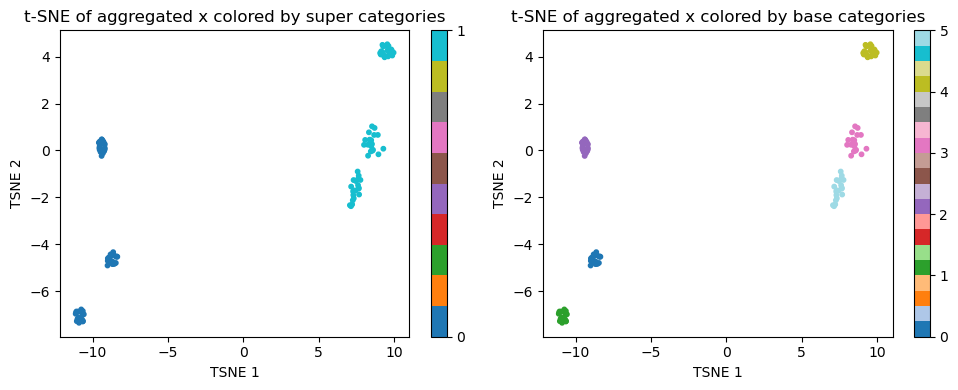

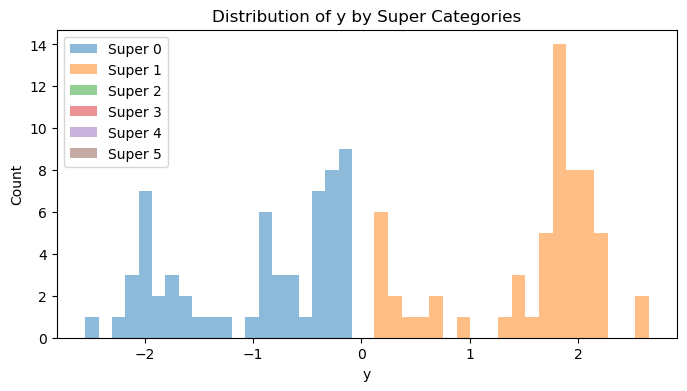

In [5]:
# Run t-SNE
tsne = TSNE(n_components=2, random_state=0)
x_embedded = tsne.fit_transform(x_agg)

# Plot t-SNE colored by super categories
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
scatter = plt.scatter(x_embedded[:, 0], x_embedded[:, 1], c=data["super_labels"], cmap="tab10", s=10)
plt.colorbar(scatter, ticks=range(6))
plt.title("t-SNE of aggregated x colored by super categories")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")

# Plot t-SNE colored by base categories
plt.subplot(1, 2, 2)
scatter = plt.scatter(x_embedded[:, 0], x_embedded[:, 1], c=data["base_labels"], cmap="tab20", s=10)
plt.colorbar(scatter, ticks=range(18))
plt.title("t-SNE of aggregated x colored by base categories")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")

plt.tight_layout()
plt.show()

# Plot distribution of y by super categories
plt.figure(figsize=(8, 4))
for super_id in range(6):
    y_vals = data["y"][data["super_labels"] == super_id]
    plt.hist(y_vals, bins=20, alpha=0.5, label=f"Super {super_id}")

plt.title("Distribution of y by Super Categories")
plt.xlabel("y")
plt.ylabel("Count")
plt.legend()
plt.show()


/home/dzhao268/anaconda3/envs/jax_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/dzhao268/anaconda3/envs/jax_env/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


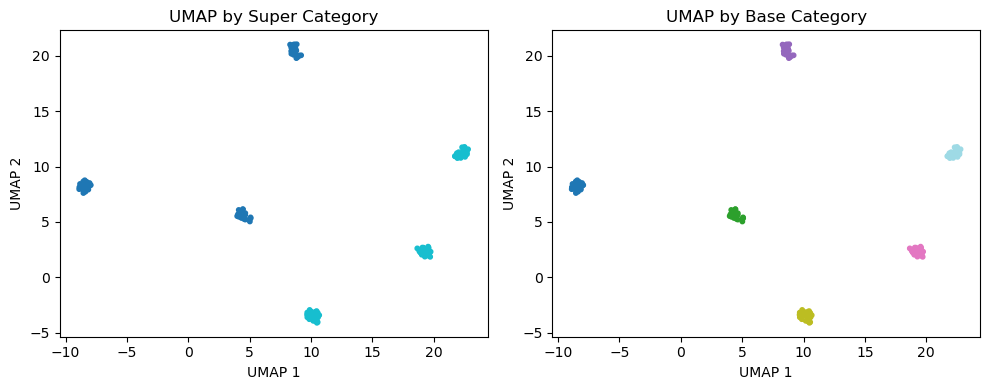

(2, 3, 10)


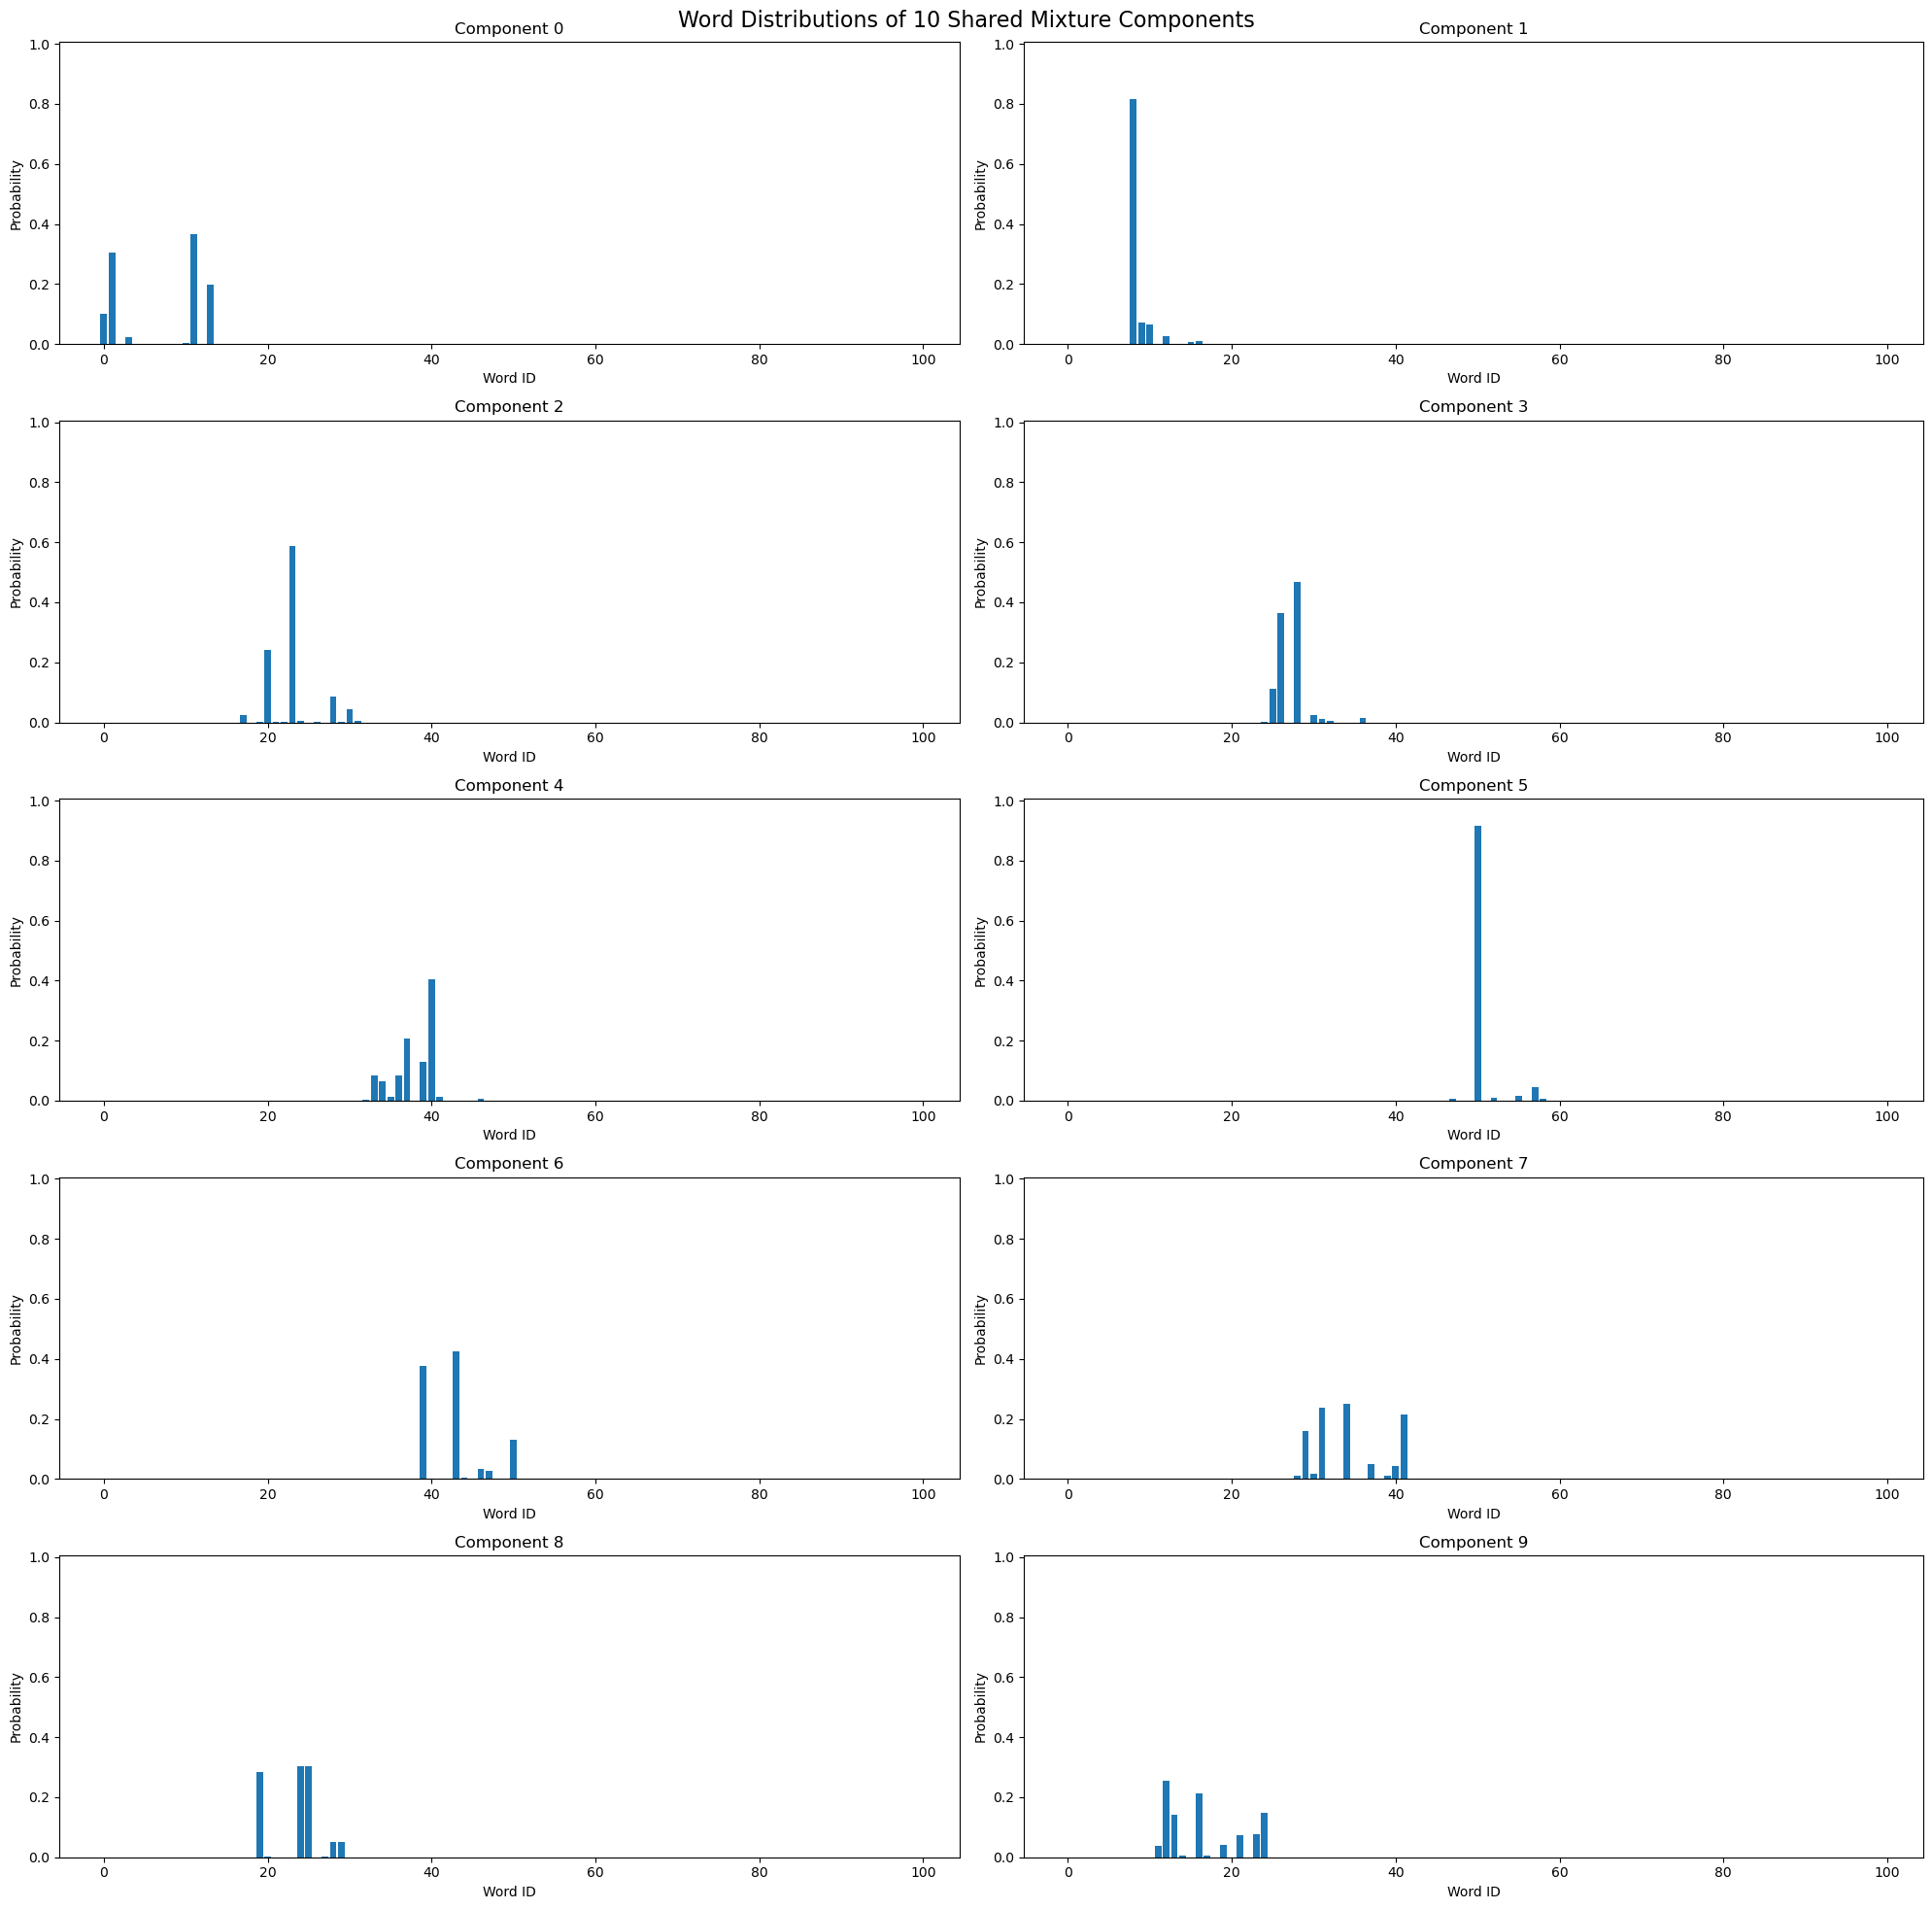

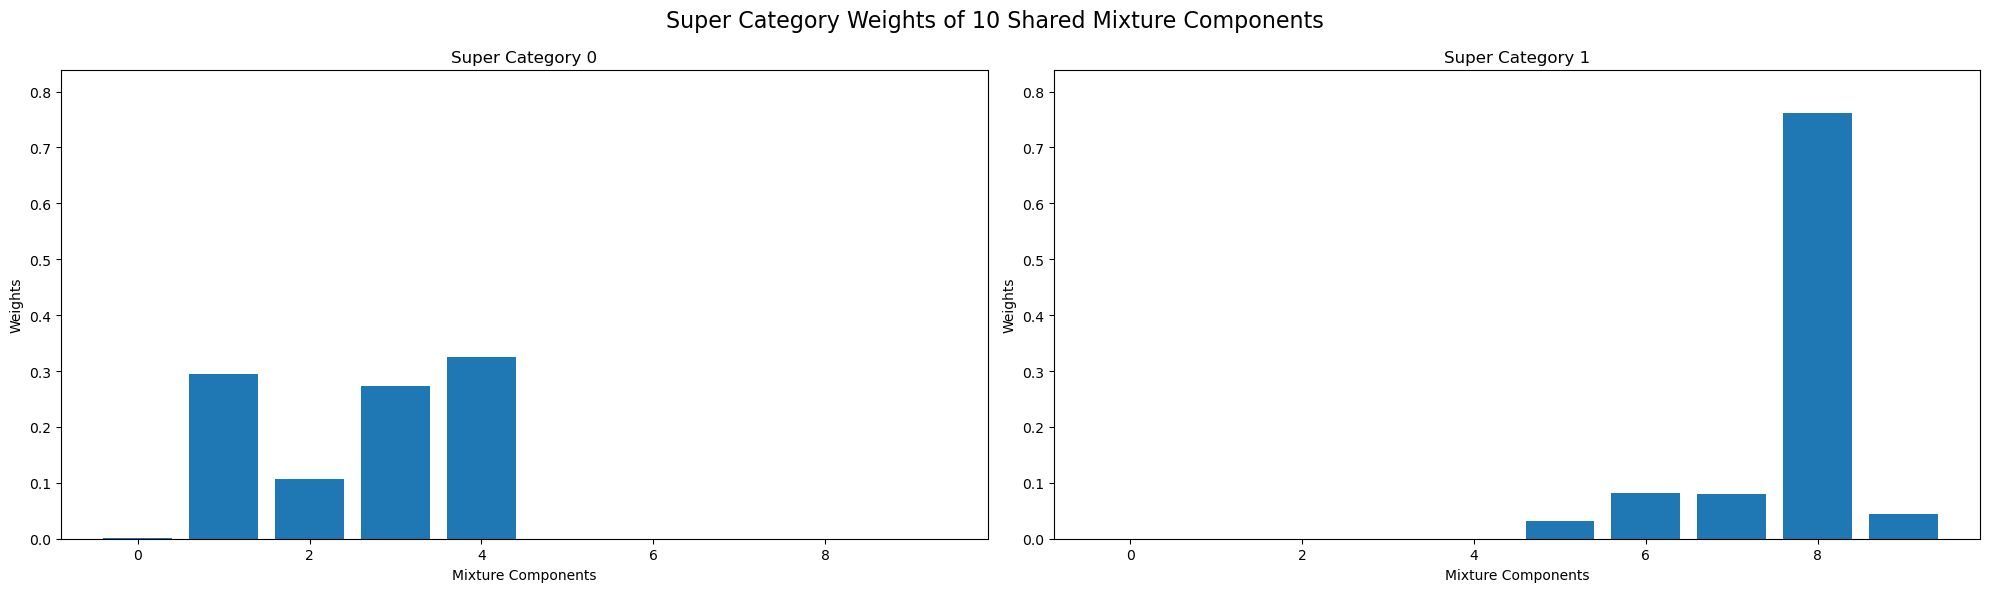

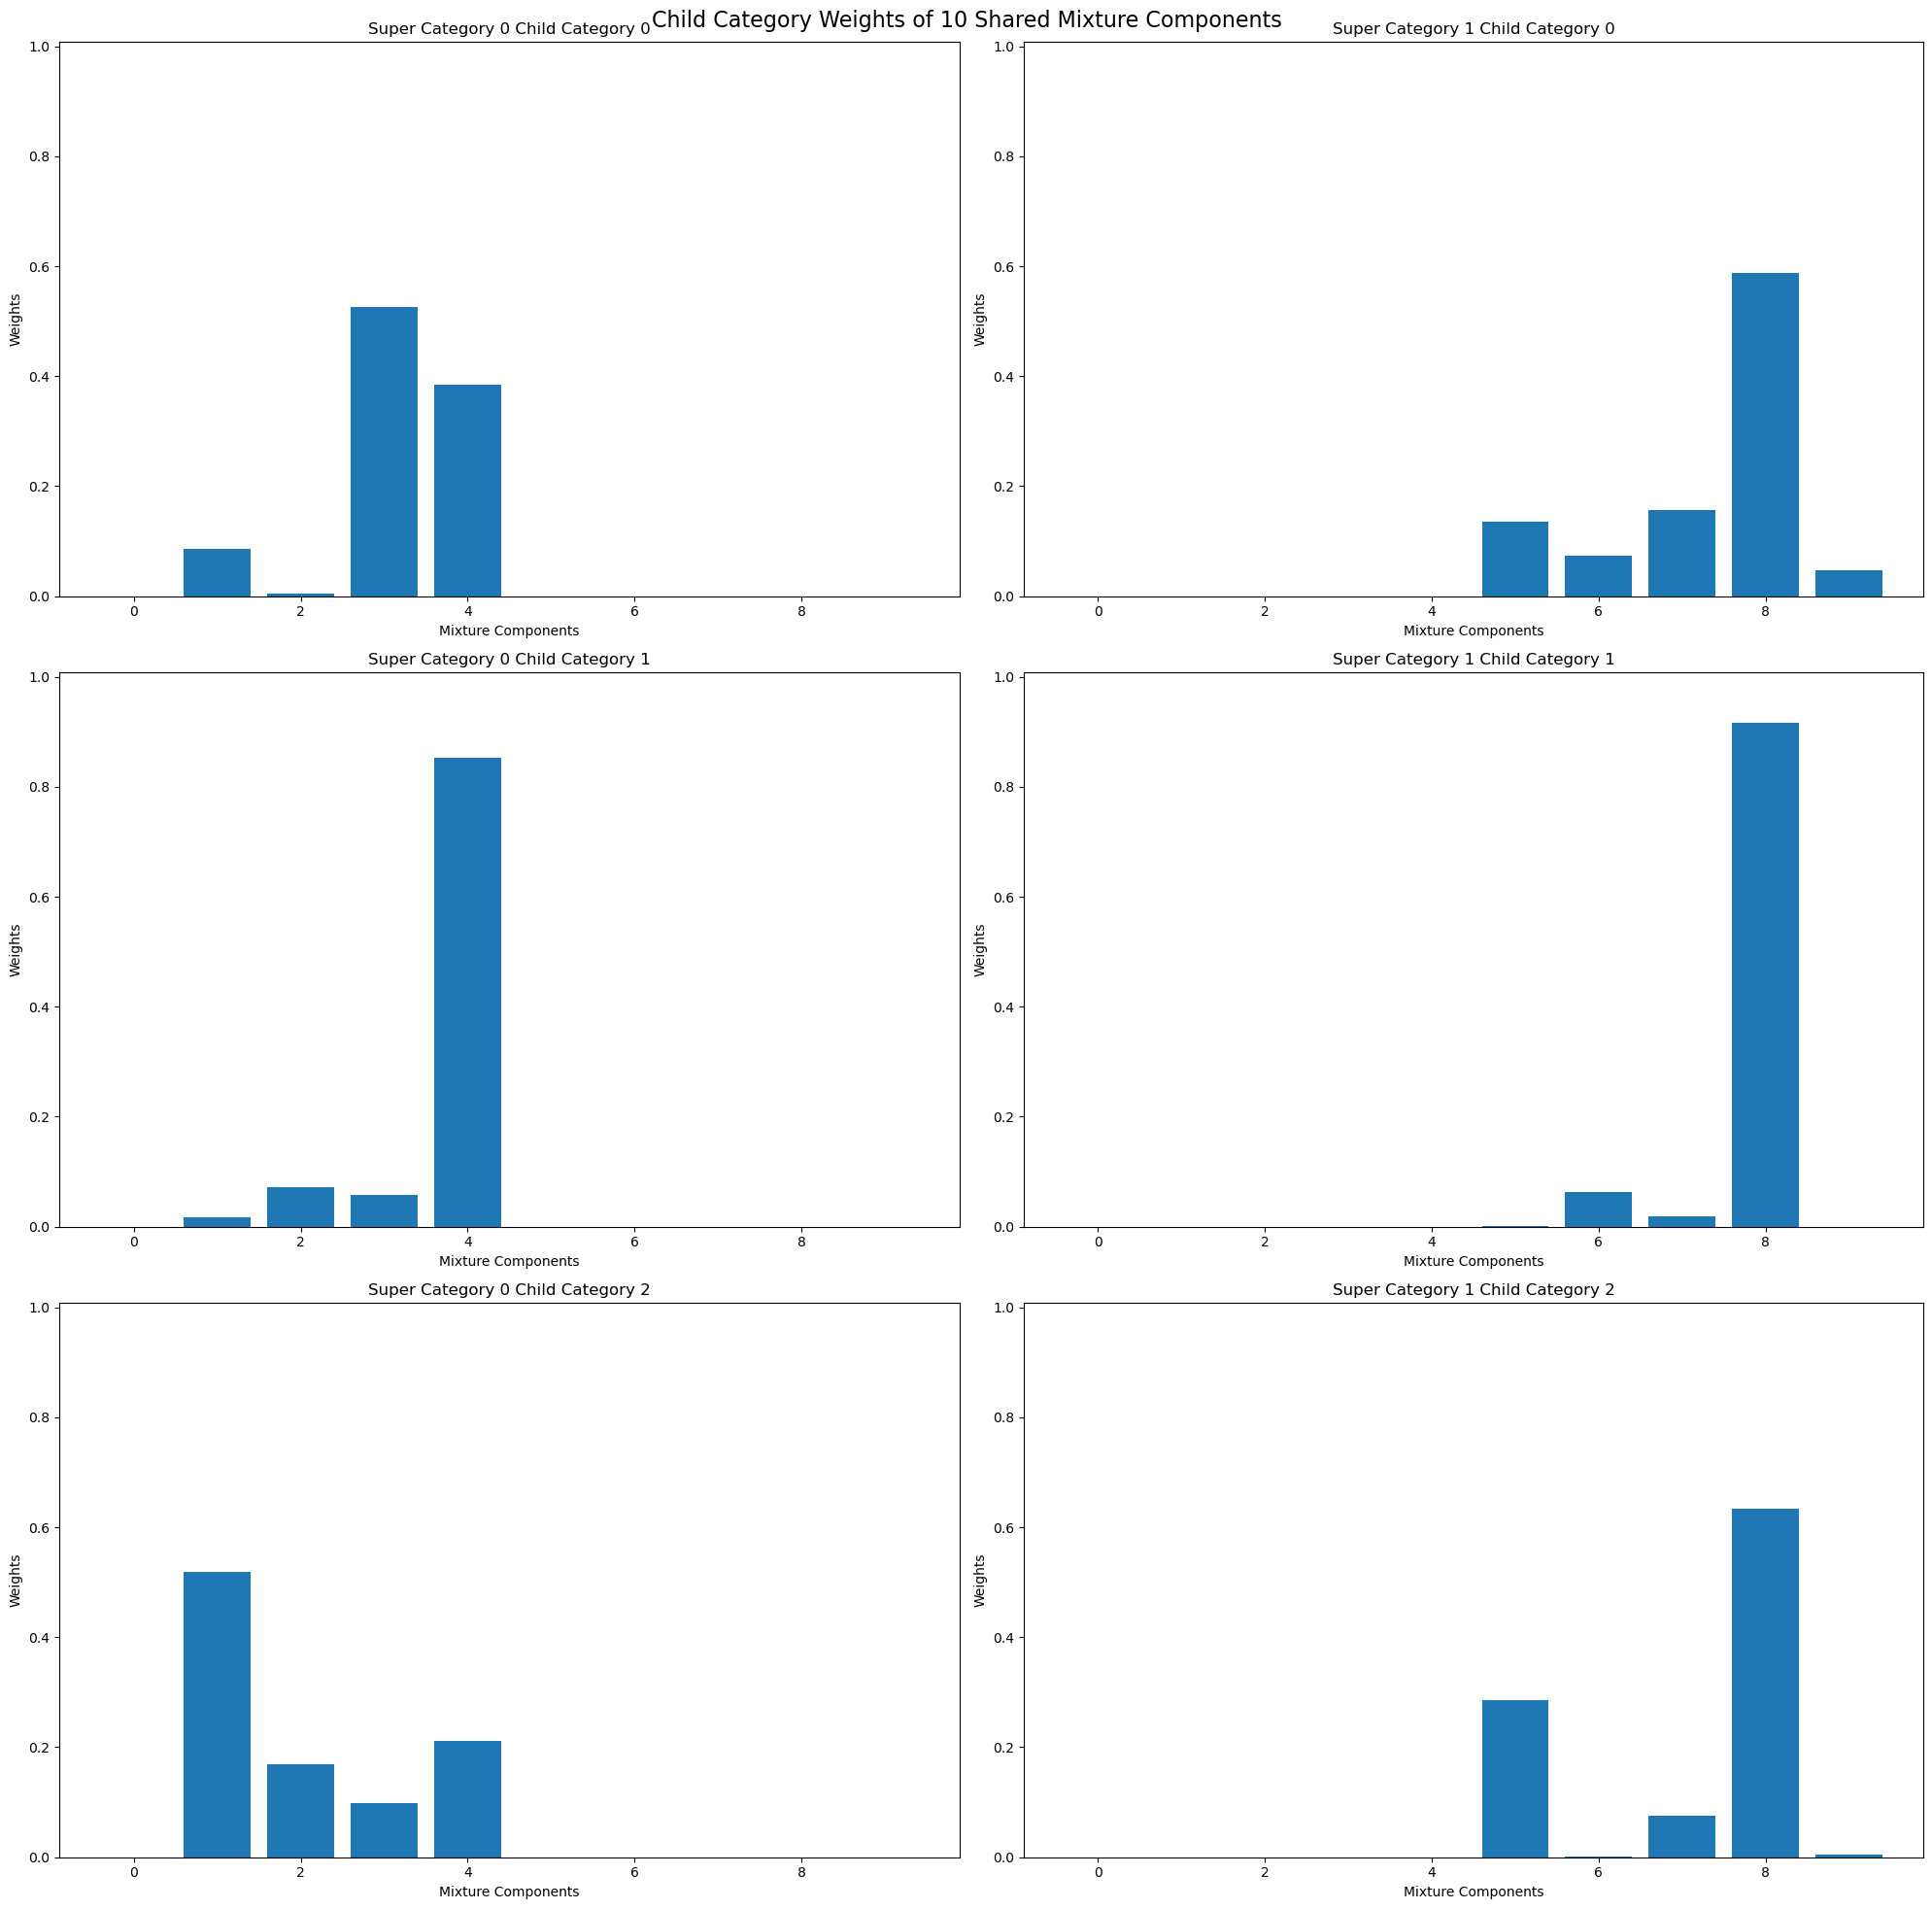

In [6]:
# === UMAP projection ===
reducer = umap.UMAP(random_state=0)
x_umap = reducer.fit_transform(x_agg)


# === UMAP Plots ===
plt.figure(figsize=(10, 4))

# Super category coloring
plt.subplot(1, 2, 1)
plt.scatter(x_umap[:, 0], x_umap[:, 1], c=data["super_labels"], cmap="tab10", s=10)
plt.title("UMAP by Super Category")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

# Base category coloring
plt.subplot(1, 2, 2)
plt.scatter(x_umap[:, 0], x_umap[:, 1], c=data["base_labels"], cmap="tab20", s=10)
plt.title("UMAP by Base Category")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.tight_layout()
plt.show()

# === Mixture Component Word Distributions ===
num_components = 10
V = data["x"].shape[-1]
word_dists = data["word_dists"]
super_mix_weights = data["super_mix_weights"]
child_mix_weights = data["child_mix_weights"]
print(child_mix_weights.shape)

# Bar plots for each component
fig, axs = plt.subplots(5, 2, figsize=(20, 20))
for i in range(num_components):
    ax = axs[i // 2, i % 2]
    ax.bar(range(V), word_dists[i])
    ax.set_title(f"Component {i}")
    ax.set_xlabel("Word ID")
    ax.set_ylabel("Probability")
    ax.set_ylim(0, word_dists.max().item() * 1.1)

fig.suptitle("Word Distributions of 10 Shared Mixture Components", fontsize=16)
plt.tight_layout()
plt.show()

# Bar plots for each component
fig, axs = plt.subplots(1, 2, figsize=(20, 6))
for i in range(2):
    ax = axs[i]
    ax.bar(range(10), super_mix_weights[i])
    ax.set_title(f"Super Category {i}")
    ax.set_xlabel("Mixture Components")
    ax.set_ylabel("Weights")
    ax.set_ylim(0, super_mix_weights.max().item() * 1.1)

fig.suptitle("Super Category Weights of 10 Shared Mixture Components", fontsize=16)
plt.tight_layout()
plt.show()

# Bar plots for each component
fig, axs = plt.subplots(3, 2, figsize=(20, 20))
for i in range(3):
    for j in range(2):
        ax = axs[i, j]
        ax.bar(range(10), child_mix_weights[j][i])
        ax.set_title(f"Super Category {j} Child Category {i}")
        ax.set_xlabel("Mixture Components")
        ax.set_ylabel("Weights")
        ax.set_ylim(0, child_mix_weights.max().item() * 1.1)

fig.suptitle("Child Category Weights of 10 Shared Mixture Components", fontsize=16)
plt.tight_layout()
plt.show()


In [7]:
@jax.jit
def mix_weights(beta):
    # Compute cumulative product of (1 - beta) along the last dimension
    beta1m_cumprod = jnp.cumprod(1.0 - beta, axis=-1)

    # Pad beta with a 1 at the end of the last dimension
    beta_padded = jnp.pad(beta, ((0, 0),) * (beta.ndim - 1) + ((0, 1),), constant_values=1.0)

    # Pad beta1m_cumprod with a 1 at the start of the last dimension
    beta1m_cumprod_padded = jnp.pad(beta1m_cumprod, ((0, 0),) * (beta.ndim - 1) + ((1, 0),), constant_values=1.0)

    # Element-wise multiplication
    weight = beta_padded * beta1m_cumprod_padded

    # Numerical stability (avoid zero weights)
    weight = jnp.maximum(weight, 1e-6)

    # Normalize across last dimension
    rlt = weight / jnp.sum(weight, axis=-1, keepdims=True)

    return rlt


In [8]:
def model(data, struct_upbd, vocab_size, seed, gen_mixture=None, device=None):
    """
    Args:
      data: (feature, label), where
            feature: (N, M, vocab_size) one-hot words per position (or None for prior)
            label:   (N,) regression targets (or None for prior)
      struct_upbd: dict like {"G0": K0, "G1": K1, ...} (top level is G0)
      vocab_size: int
      device: unused (kept for API parity)
    """
    key = random.PRNGKey(seed)
    param_dims = list(struct_upbd.values())
    param_dims.reverse()
    cluster_dims = param_dims[:-1]  # no G0
    cluster_dims.reverse()

    # -----------------------
    # Data handling
    # -----------------------
    feature = data[0]          # expected shape (N, M, vocab_size)
    N = feature.shape[0]
    M = feature.shape[1]
    label = data[1] 

    # ------------------------
    # Global/structural params
    # ------------------------
    struct_params = {}
    struct_params["gamma"]      = numpyro.param("model_gamma",      jnp.asarray([N/10.]), constraint=constraints.positive)
    struct_params["dir_alpha"]  = numpyro.param("model_dir_alpha",  jnp.asarray([1./vocab_size]), constraint=constraints.positive)
    struct_params["nig_mu"]     = numpyro.param("model_nig_mu",     jnp.asarray([0.0]))
    struct_params["nig_kappa"]  = numpyro.param("model_nig_kappa",  jnp.asarray([1.0]), constraint=constraints.positive)
    struct_params["nig_alpha"]  = numpyro.param("model_nig_alpha",  jnp.asarray([1.0]), constraint=constraints.positive)
    struct_params["nig_beta"]   = numpyro.param("model_nig_beta",   jnp.asarray([1.0]), constraint=constraints.positive)

    # alpha/eta tensors across hierarchy
    for parent_level in range(len(struct_upbd) - 1):
        child_level = parent_level + 1
        full_dim = child_level + 1  

        base = numpyro.param(
            f"model_alpha{parent_level}",
            N/(10.*child_level)*jnp.ones(tuple(param_dims[-child_level:-1])),
            constraint=constraints.positive,
        )
        struct_params[f"alpha{parent_level}"] = jnp.expand_dims(base, -1) * jnp.ones(tuple(param_dims[-child_level:]))
        assert struct_params[f"alpha{parent_level}"].shape == tuple(param_dims[-child_level:])

        struct_params[f"eta{parent_level}"] = numpyro.param(
            f"model_eta{parent_level}",
            10*jnp.ones(tuple(cluster_dims[:child_level])),
            constraint=constraints.positive,
        )

    # Last level alpha (no eta)
    last_idx = len(struct_upbd) - 1
    base_last = numpyro.param(
        f"model_alpha{last_idx}",
        jnp.ones(tuple(param_dims[:-1])),
        constraint=constraints.positive,
    )
    struct_params[f"alpha{last_idx}"] = jnp.expand_dims(base_last, -1) * jnp.ones(tuple(param_dims))
    assert struct_params[f"alpha{last_idx}"].shape == tuple(param_dims)

    # ---------------
    # Stick-breaking
    # ---------------
    struct_values = {}

    # Top-level Beta sticks B0 -> G0 weights
    K0 = param_dims[-1]
    B0_a = jnp.ones((K0,))  # shape (K0,)
    B0_b = jnp.broadcast_to(struct_params["gamma"], (K0,))
    key, sub = random.split(key)
    beta_0 = dist.Beta(B0_a, B0_b).sample(sub)
    struct_values["P0"] = [B0_a, B0_b]
    struct_values["B0"] = beta_0
    struct_values["G0"] = mix_weights(beta_0)[..., :-1]  # (K0,)
    assert struct_values["G0"].shape == (K0,)

    # Lower levels
    for parent_level in range(len(struct_upbd) - 1):
        child_level = parent_level + 1
        full_dim = child_level + 1  # number of dims for this plate

        # shapes like in your code:
        # alpha * G_parent and alpha * (1 - cumsum(G_parent))
        G_parent = struct_values[f"G{parent_level}"]  # shape param_dims[-(parent_level+1):]
        alpha_param = struct_params[f"alpha{parent_level}"]  # shape param_dims[-child_level:]
        param_alpha = alpha_param * G_parent
        param_beta = alpha_param * (1.0 - jnp.cumsum(G_parent, axis=-1))

        shape_needed = tuple(param_dims[-full_dim:])
        a = jnp.broadcast_to(jnp.expand_dims(param_alpha, 0), shape_needed)
        b = jnp.broadcast_to(jnp.expand_dims(param_beta, 0), shape_needed)

        key, sub = random.split(key)
        beta = dist.Beta(a, b).sample(sub)
        struct_values[f"P{child_level}"] = [a, b]
        struct_values[f"B{child_level}"] = beta
        struct_values[f"G{child_level}"] = mix_weights(beta)[..., :-1] 
        assert struct_values[f"G{child_level}"].shape == tuple(param_dims[-full_dim:])
        assert struct_values[f"P{child_level}"][0].shape == tuple(param_dims[-full_dim:])
        assert struct_values[f"P{child_level}"][1].shape == tuple(param_dims[-full_dim:])

    # ---------------
    # Cluster weights
    # ---------------
    for parent_level in range(len(struct_upbd) - 1):
        child_level = parent_level + 1
        full_dim = child_level + 1
        eta = struct_params[f"eta{parent_level}"]  # shape param_dims[-full_dim:-1]

        key, sub = random.split(key)
        a = jnp.ones_like(eta)
        b = eta
        beta = dist.Beta(a, b).sample(sub)
        assert beta.shape == tuple(cluster_dims[:child_level])
        struct_values[f"LP{parent_level}"] = [a, b]
        struct_values[f"LB{parent_level}"] = beta
        struct_values[f"LG{parent_level}"] = mix_weights(beta)[..., :-1]  # categorical probs over next level
        assert struct_values[f"LG{parent_level}"].shape == tuple(cluster_dims[:child_level])

    # -----------------------
    # Mixture components
    # -----------------------
    # Topics over vocab
    G0_size = struct_upbd["G0"]
    mixture_components = {}
    if gen_mixture is not None:
        assert gen_mixture.shape == (G0_size, vocab_size)
        mixture_components["generation"] = gen_mixture
    else:
        key, sub = random.split(key)
        mixture_components["generation"] = dist.Dirichlet(
                struct_params["dir_alpha"]
                * jnp.ones((vocab_size))
            ).sample(sub, sample_shape=(G0_size,))
        assert mixture_components["generation"].shape == (G0_size, vocab_size)
    # Regression components via NIG prior
    key, sub = random.split(key)
    sigma = dist.InverseGamma(
            jnp.broadcast_to(struct_params["nig_alpha"], (G0_size,)),
            jnp.broadcast_to(struct_params["nig_beta"],  (G0_size,))
        ).sample(sub)
    assert sigma.shape == (G0_size,)
    key, sub = random.split(key)
    mu = dist.Normal(
            jnp.broadcast_to(struct_params["nig_mu"], (G0_size,)),
            jnp.sqrt(sigma / jnp.broadcast_to(struct_params["nig_kappa"], (G0_size,)))
        ).sample(sub)
    assert mu.shape == (G0_size,)
    mixture_components["regression_sigma"] = sigma
    mixture_components["regression_mu"] = mu

    # ---------------------------------
    # Per-document hierarchical routing
    # ---------------------------------
    assigned_zs = [jnp.zeros((N,), dtype=jnp.int32)]  # seed like your torch.zeros long
    doc_values = {}

    # Walk down the cluster tree
    for level in range(len(struct_upbd) - 1):
        # cluster_weights[L{level}] has dims over the parent categories, last dim = choices at this level
        W = struct_values[f"LG{level}"][None, ...]  # shape e.g. (..., K_level)
        # Build advanced indexing tuple from already-sampled parent zs
        # assigned_zs holds arrays of shape (N,), one per parent axis.
        index_tuple = tuple(assigned_zs[:])
        # param -> (N, K_level)
        param = W[index_tuple]
        assert param.shape == (N, struct_values[f"LG{level}"].shape[-1])
        key, sub = random.split(key)
        z = dist.Categorical(probs=param).sample(sub)
        assigned_zs.append(z)

    # reverse to align with your later indexing usage
    assigned_zs = assigned_zs[::-1]


    # Document-level stick-breaking at bottom: construct Beta params using G_{L} and alpha_{L}
    bottom_G = struct_values[f"G{len(struct_upbd)-1}"][None, ...]  # shape (K0,) broadcastable with per-doc gather
    bottom_alpha = struct_params[f"alpha{len(struct_upbd)-1}"][None, ...]

    # Gather per-doc parent path for alpha and weights_prior
    # For G_{L} (topic base weights), use parent indices in assigned_zs[:-1]
    idx_tuple_weights = tuple(assigned_zs[:-1])
    batch_idx = jnp.arange(N)
    indices = (batch_idx, *idx_tuple_weights)  

    weights_prior = bottom_G[indices + (slice(None),)]  # (N, G0)
    assert weights_prior.shape == (N, G0_size)
    concentrate = bottom_alpha[indices + (slice(None),)]  # (N, G0)
    assert concentrate.shape == (N, G0_size)

    param_alpha = concentrate * weights_prior
    param_beta = concentrate * (1.0 - jnp.cumsum(weights_prior, axis=-1))

    key, sub = random.split(key)
    beta_doc = dist.Beta(param_alpha, param_beta).sample(sub)  # (N, G0)
    doc_values["P"] = [param_alpha, param_beta]
    doc_values["B"]  = beta_doc

    topic_dist = mix_weights(beta_doc)[..., :-1]   # (N, G0)
    doc_values["G"] = topic_dist
    assert topic_dist.shape == (N, G0_size)

    # ----- Words -----
    # Per-token topic → per-token word dist, then one-hot word obs via Multinomial(1, .)
    topic_over_docs = jnp.broadcast_to(jnp.expand_dims(topic_dist, axis=1), (N, M, G0_size))
    key, sub = random.split(key)
    z_gen = dist.Categorical(probs=topic_over_docs).sample(sub)  # (N, M)
    obs = feature

    # ----- Regression -----
    key, sub = random.split(key)
    z_reg = dist.Categorical(probs=topic_dist).sample(sub)  
    reg = label

    # Recreate category_assignments like your torch.stack(cat_zs, dim=1)
    cat_zs = assigned_zs[:-1][::-1]  # drop the seed, reverse to original order
    category_assignments = jnp.stack(cat_zs, axis=1) if len(cat_zs) > 0 else jnp.zeros((N, 0), dtype=jnp.int32)

    return {
        "struct_params": struct_params,
        "struct_values": struct_values,
        "mixture_components": mixture_components,
        "category_assignments": category_assignments,
        "doc_values": doc_values,
        "words": {
            "z_gen": z_gen,
            "z_reg": z_reg,
            "obs": obs,
            "reg": reg,
        },
    }


In [9]:
# @jax.jit
def compute_log_joint_prob(state, struct_upbd):
    """
    Gibbs sampler for HDMM with proper JAX key handling.
    """
    # Unpack state
    struct_values = state["struct_values"]
    generation_components = state["mixture_components"]["generation"]
    regression_mu = state["mixture_components"]["regression_mu"]
    regression_sigma = state["mixture_components"]["regression_sigma"]
    category_assignments = state["category_assignments"]
    doc_values = state["doc_values"]
    words = state["words"]
    z_gen = words["z_gen"]
    z_reg = words["z_reg"]
    obs = words["obs"]
    reg = words["reg"]
    doc_values = state["doc_values"]

    # ---------------
    # Joint log-probability
    # ---------------
    log_prob = 0.0

    # Top-level Beta sticks B0 -> G0 weights
    B0_a, B0_b  = struct_values["P0"]
    beta_logp = jnp.sum(dist.Beta(B0_a, B0_b).log_prob(struct_values["B0"]))
    assert not jnp.any(jnp.isnan(beta_logp))
    log_prob += beta_logp

    # Lower levels
    for parent_level in range(len(struct_upbd) - 1):
        child_level = parent_level + 1
        a, b = struct_values[f"P{child_level}"]
        beta_logp = jnp.sum(dist.Beta(a, b).log_prob(struct_values[f"B{child_level}"]))
        assert not jnp.any(jnp.isnan(beta_logp))
        log_prob += beta_logp

    # Cluster weights
    for parent_level in range(len(struct_upbd) - 1):
        a, b = struct_values[f"LP{parent_level}"]
        cluster_logp = jnp.sum(dist.Beta(a, b).log_prob(struct_values[f"LB{parent_level}"]))
        assert not jnp.any(jnp.isnan(cluster_logp))
        log_prob += cluster_logp

    # Document-level
    category_assignments[:0]
    param_alpha, param_beta = doc_values["P"]
    doc_cat_logp = jnp.sum(dist.Beta(param_alpha, param_beta).log_prob(doc_values["B"]))
    assert not jnp.any(jnp.isnan(doc_cat_logp))
    log_prob += doc_cat_logp

    topic_prob = jnp.take_along_axis(doc_values["G"], z_gen, axis=1)
    assert not jnp.any(jnp.isnan(topic_prob))
    log_prob += jnp.sum(jnp.log(topic_prob + 1e-12))

    gen_param = generation_components[z_gen]  # (N, M, V)
    word_prob = dist.Multinomial(total_count=1, probs=gen_param).log_prob(obs)
    assert not jnp.any(jnp.isnan(word_prob))
    log_prob += jnp.sum(word_prob)

    reg_prob = dist.Normal(loc=regression_mu[z_reg], scale=regression_sigma[z_reg]).log_prob(reg)
    assert not jnp.any(jnp.isnan(reg_prob))
    log_prob += jnp.sum(reg_prob)

    return log_prob

In [10]:
@jax.jit
def suffix_sum(x: jnp.ndarray) -> jnp.ndarray:
    """
    Compute suffix sums along the last dimension of a tensor.
    Each entry is the sum of all elements to its right.
    The last element along that dimension is always 0.
    
    Example:
        x = jnp.array([1,2,3])
        suffix_sum(x) -> [5,3,0]
        
        x = jnp.array([[1,2,3],[4,5,6]])
        suffix_sum(x) -> [[5,3,0],
                           [11,6,0]]
    """
    # Flip along the last dimension
    rev = jnp.flip(x, axis=-1)
    # Cumulative sum on the flipped tensor
    rev_cumsum = jnp.cumsum(rev, axis=-1)
    # Flip back
    suffix = jnp.flip(rev_cumsum, axis=-1)
    # Subtract original to exclude current element
    suffix = suffix - x
    return suffix

In [11]:
@jax.jit
def word_category_conditional(key, word, weight, components):
    """
    Sample category assignment for a single word given mixture weights and component distributions.
    Args:
        key: JAX PRNGKey
        word: (V,) one-hot vector of the word
        weight: (K,) mixture weights for the document
        components: (K, V) component-word distributions 
    Returns:
        sample: int, sampled category index from 0 to K-1
        new_key: updated JAX PRNGKey
    """

    gen_dist = dist.Multinomial(total_count=1, probs=components)
    log_probs = gen_dist.log_prob(word)
    un_normalized = log_probs + jnp.log(weight + 1e-12)
    cat_prob = jax.nn.softmax(un_normalized, axis=-1)

    key, sub = random.split(key)
    sample = dist.Categorical(probs=cat_prob).sample(sub)
    return sample, key


In [12]:
@jax.jit
def reg_category_conditional(key, score, weight, components):
    """
    Sample category assignment for a single regression score given mixture weights and component distributions.
    Args:
        key: JAX PRNGKey
        score: float, regression score
        weight: (K,) mixture weights for the document
        components: (K, 2) component regression parameters (mean, variance)
    Returns:
        sample: int, sampled category index from 0 to K-1
        new_key: updated JAX PRNGKey
    """
    reg_dist = dist.Normal(loc=components[0], scale=jnp.sqrt(components[1]))
    log_probs = reg_dist.log_prob(score)
    un_normalized = log_probs + jnp.log(weight + 1e-12)

    cat_prob = jax.nn.softmax(un_normalized, axis=-1)
    key, sub = random.split(key)
    sample = dist.Categorical(probs=cat_prob).sample(sub)
    return sample, key

In [13]:
@jax.jit
def doc_categories_conditional(key, nu_doc, nu1, nu2, params1, params2, doc_prior, doc_concentrate, cluster_prob0, cluster_prob1, S, C):
    """
    Sample document category assignments at two levels given stick-breaking weights and cluster probabilities.
    Args:
        key: JAX PRNGKey
        nu_doc: (K,) document-level stick-breaking weights
        nu1: (S,) level 1 stick-breaking weights
        nu2: (C, S) level 2 stick-breaking weights
        params1: (2,) Beta parameters for level 1 sticks
        params2: (2,) Beta parameters for level 2 sticks
        doc_prior: (K,) prior weights for document-level sticks
        doc_concentrate: scalar, concentration parameter for document-level sticks
        cluster_prob0: (S,) cluster probabilities at level 1
        cluster_prob1: (S, C) cluster probabilities at level 2
        S: int, number of clusters at level 1
        C: int, number of clusters at level 2
    Returns:
        new_cat: (2,) array of sampled category indices [level1, level2]
        new_key: updated JAX PRNGKey
    """
    
    K = 10
    nu_doc = nu_doc[None, None, :]  # (1, 1, K)
    nu_1_log_prob = dist.Beta(params1[0], params1[1]).log_prob(nu1)
    nu_1_log_prob = jnp.sum(nu_1_log_prob, axis=-1)  # (S,)
    nu_1_log_prob = nu_1_log_prob[None, :] # (1, S)
    
    nu_2_log_prob = dist.Beta(params2[0], params2[1]).log_prob(nu2)
    nu_2_log_prob = jnp.sum(nu_2_log_prob, axis=-1)  # (C, S)


    param_alpha = doc_concentrate * doc_prior
    param_beta = doc_concentrate * (1.0 - jnp.cumsum(doc_prior, axis=-1))

    mu_doc_log_prob = dist.Beta(param_alpha, param_beta).log_prob(nu_doc)
    mu_doc_log_prob = jnp.sum(mu_doc_log_prob, axis=-1)  # (C, S)

    level1_prob =  jnp.log(cluster_prob0[None, :])  # (1, S)
    level2_prob =  jnp.log(jnp.transpose(cluster_prob1))  # (C, S)

    un_normalized = nu_1_log_prob + nu_2_log_prob + mu_doc_log_prob + level1_prob + level2_prob  # (C, S)
    prob = jax.nn.softmax(un_normalized.reshape(-1))

    key, sub = random.split(key)
    sample = dist.Categorical(probs=prob).sample(sub)
    new_cat1 = sample // S
    new_cat0 = sample % S
    new_cat = jnp.array([new_cat0, new_cat1])
    return new_cat, key

In [14]:
@jax.jit
def doc_weight_conditional(key, nu_doc, params, word_cats, reg_cats):
    """
    Sample document-level stick-breaking weights given category assignments and Beta parameters.
    Args:
        key: JAX PRNGKey
        nu_doc: (K,) current document-level stick-breaking weights
        params: list of two (K,) arrays, Beta parameters [alpha, beta]
        word_cats: (N_word,) array of word category assignments
        reg_cats: (N_reg,) array of regression category assignments
    Returns:
        new_params: list of two (K,) arrays, updated Beta parameters [alpha, beta
        new_key: updated JAX PRNGKey
    """
    K = 10
    cat_count = jnp.bincount(word_cats.ravel(), length=K)
    cat_idx = jnp.arange(K)
    reg_count = jnp.bincount(reg_cats.ravel(), length=K)
    cat_count = cat_count + reg_count

    alpha_bias = jnp.zeros_like(nu_doc, dtype=jnp.int32).at[cat_idx].set(cat_count)
    beta_bias = suffix_sum(alpha_bias)

    new_params = [params[0] + alpha_bias, params[1] + beta_bias]
    return new_params, key


In [15]:
@jax.jit
def super_cluster_weight_conditional(key, nu_cluster, params, cluster_cats):
    """
    Sample super-cluster-level stick-breaking weights given category assignments and Beta parameters.
    Args:
        key: JAX PRNGKey
        nu_cluster: (S,) current super-cluster-level stick-breaking weights
        params: list of two (S,) arrays, Beta parameters [alpha, beta]
        cluster_cats: (N_cluster,) array of super-cluster category assignments
    Returns:
        new_params: list of two (S,) arrays, updated Beta parameters [alpha, beta
        new_key: updated JAX PRNGKey
    """
    S = 2
    cat_count = jnp.bincount(cluster_cats.ravel(), length=S)
    cat_idx = jnp.arange(S)

    alpha_bias = jnp.zeros_like(nu_cluster, dtype=jnp.int32).at[cat_idx].set(cat_count)
    beta_bias = suffix_sum(alpha_bias)

    new_params = [params[0] + alpha_bias, params[1] + beta_bias]
    return new_params, key

In [16]:
@jax.jit
def base_cluster_weight_conditional(key, nu_cluster, params, cluster_cats):
    """
    Sample base-cluster-level stick-breaking weights given category assignments and Beta parameters.
    Args:
        key: JAX PRNGKey
        nu_cluster: (C,) current base-cluster-level stick-breaking weights
        params: list of two (C,) arrays, Beta parameters [alpha, beta]
        cluster_cats: (N_cluster,) array of base-cluster category assignments under one super-cluster
    Returns:
        new_params: list of two (C,) arrays, updated Beta parameters [alpha, beta
        new_key: updated JAX PRNGKey
    """
    C = 3
    cat_count = jnp.bincount(cluster_cats.ravel(), length=C)
    cat_idx = jnp.arange(C)

    alpha_bias = jnp.zeros_like(nu_cluster, dtype=jnp.int32).at[cat_idx].set(cat_count)
    beta_bias = suffix_sum(alpha_bias)

    new_params = [params[0] + alpha_bias, params[1] + beta_bias]
    return new_params, key

In [17]:
@jax.jit
def cat_weight_conditional(key, nu, params, word_cats, reg_cats):
    """
    Sample category-level stick-breaking weights given category assignments and Beta parameters.
    Args:
        key: JAX PRNGKey
        nu: (K,) current category-level stick-breaking weights
        params: list of two (K,) arrays, Beta parameters [alpha, beta]
        word_cats: (N_word,) array of word category assignments
        reg_cats: (N_reg,) array of regression category assignments
    Returns:
        new_params: list of two (K,) arrays, updated Beta parameters [alpha, beta
        new_key: updated JAX PRNGKey
    """ 
    K = 10

    cat_count = jnp.bincount(word_cats.ravel(), length=K)
    cat_idx = jnp.arange(K)
    reg_count = jnp.bincount(reg_cats.ravel(), length=K)
    cat_count = cat_count + reg_count

    alpha_bias = jnp.zeros_like(nu, dtype=jnp.int32).at[cat_idx].set(cat_count)
    beta_bias = suffix_sum(alpha_bias)

    new_params = [params[0] + alpha_bias, params[1] + beta_bias]

    assert new_params[0].shape == (K,)
    assert new_params[1].shape == (K,)
    return new_params, key

In [18]:
@jax.jit
def reg_component_conditional(key, obs, params):
    """
    Sample regression component parameters given assigned observations and Normal-Inverse-Gamma prior.
    Args:
        key: JAX PRNGKey
        obs: (N_obs,) array of assigned regression observations
        params: list of four scalars [mu, kappa, alpha, beta] for the NIG prior
    Returns:
        new_params: list of two scalars [new_mu, new_sigma] for the sampled regression component
        new_key: updated JAX PRNGKey
    """
    count = float(obs.size)
    mean = jnp.mean(obs)
    sum_var = jnp.sum((obs - mean) ** 2, keepdims=True)
    kappa = params[1] + count
    mu = (params[1] * params[0] + count * mean) / kappa
    alpha = params[2] + count / 2
    beta = params[3] + 0.5 * sum_var + (params[1] * count * (mean - params[0]) ** 2) / (2 * kappa)

    key, sub = random.split(key)
    new_sigma = dist.InverseGamma(alpha, beta).sample(sub)
    key, sub = random.split(key)
    new_mu = dist.Normal(mu, jnp.sqrt(new_sigma / kappa)).sample(sub)
    return [jnp.squeeze(new_mu), jnp.squeeze(new_sigma)], key

In [19]:
@jax.jit
def gen_component_conditional(key, obs, params):
    """
    Sample generation component parameters given assigned observations and Dirichlet prior.
    Args:
        key: JAX PRNGKey
        obs: (N_obs, V) array of assigned one-hot word observations
        params: (V,) array of Dirichlet prior parameters
    Returns:
        sample: (V,) array of sampled generation component parameters
        new_key: updated JAX PRNGKey
    """
    value = jnp.sum(obs, axis=0)

    new_params = params + value

    key, sub = random.split(key)
    sample = dist.Dirichlet(new_params).sample(sub)
    return sample, key

In [20]:
def reverse_stick_breaking(pi, eps=1e-12):
    """
    Batched reverse stick-breaking transform (numerically stable).
    
    Args:
        pi: jnp.ndarray with shape (..., K)
            Last dimension is categorical distribution weights, should sum to ~1.
    Returns:
        v: jnp.ndarray with shape (..., K), stick-breaking variables.
    """
    K = pi.shape[-1]

    # normalize to avoid drift
    pi = pi / (jnp.sum(pi, axis=-1, keepdims=True) + eps)

    def body_fun(carry, pi_k):
        remaining = jnp.clip(carry, a_min=eps)   # avoid 0 or negative
        v_k = pi_k / remaining
        remaining = remaining - pi_k
        return remaining, v_k

    remaining0 = jnp.ones(pi.shape[:-1])
    _, v_part = jax.lax.scan(body_fun, remaining0, jnp.moveaxis(pi[..., :-1], -1, 0))
    v_part = jnp.moveaxis(v_part, 0, -1)

    # last entry: set to 1.0 explicitly
    last = jnp.ones_like(v_part[..., :1])
    v = jnp.concatenate([v_part, last], axis=-1)
    return v


In [ ]:
def beta_moments_estimate(x, var0=1e-2, eps=1e-6):
    """
    Method-of-moments estimate for Beta(alpha, beta) when each batch element has only 1 sample.
    Assumes a fixed small variance var0.

    Args:
        x: jnp.ndarray with shape (...,), samples in (0,1), each element is a separate distribution.
        var0: float, assumed variance for all distributions.
        eps: float, numerical stability.

    Returns:
        a, b: jnp.ndarray with shape (...,), estimated alpha and beta.
    """
    x = jnp.asarray(x)
    x = jnp.clip(x, eps, 1 - eps)

    # Compute pseudo-term using fixed variance
    term = (x * (1 - x) / var0) - 1.0
    term = jnp.maximum(term, 1e-6)

    a = jnp.maximum(x * term, 1e-8)
    b = jnp.maximum((1 - x) * term, 1e-8)

    return a, b


In [22]:
def row_counts(x, K):
    """
    Args:
        x: jnp.ndarray of shape (n, m), entries in 0..K-1
        K: number of categories

    Returns:
        counts: jnp.ndarray of shape (n, K), counts per row
    """
    return jax.vmap(lambda row: jnp.bincount(row, length=K))(x)

In [23]:
def transfer_ground_truth_to_state(post_state, struct_upbd, data):
    """
    Given the ground truth mixture components and category assignments,
    transfer them to the HDMM state format for initializing the Gibbs sampler.

    Args:
        post_state: dict, the HDMM state returned by the model function.
        struct_upbd: dict, structure upper bounds.
        data: dict, containing 'word_dists' and 'category_assignments'.
    Returns:
        new_state: dict, HDMM state with ground truth components and assignments.
    """
    eps = 1e-3
    N, M, V = data["x"].shape
    K = struct_upbd["G0"]
    S = struct_upbd["G1"]
    C = struct_upbd["G2"]
    ground_truth_state = {"struct_values": {}, "mixture_components": {}, "category_assignments": None, "doc_values": {}, "words": {}}

    # Transfer generation components
    ground_truth_state["mixture_components"]["generation"] = data["word_dists"]
    ground_truth_state["mixture_components"]["generation"] = jnp.clip(ground_truth_state["mixture_components"]["generation"], eps, 1.0-eps)
    assert ground_truth_state["mixture_components"]["generation"].shape == (K, V)

    ground_truth_state["mixture_components"]["regression_mu"] = data["reg_means"]
    ground_truth_state["mixture_components"]["regression_sigma"] = data["reg_std"]
    assert ground_truth_state["mixture_components"]["regression_mu"].shape == (K,)
    assert ground_truth_state["mixture_components"]["regression_sigma"].shape == (K,)
    assert ground_truth_state["mixture_components"]["generation"].shape == (K, V)

    # Transfer category assignments
    ground_truth_state["category_assignments"] = jnp.stack([data["super_labels"], data["base_labels"]], axis=1)  # (N, 2)
    assert ground_truth_state["category_assignments"].shape == (N, 2)

    # Transfer document-level stick-breaking weights
    ground_truth_state["words"]["z_gen"] = data["x_labels"]  # (N, M)
    ground_truth_state["words"]["z_reg"] = data["y_labels"]  # (N,)
    ground_truth_state["words"]["obs"] = data["x"]  # (N, M, V)
    ground_truth_state["words"]["reg"] = data["y"]  # (N,)
    assert ground_truth_state["words"]["z_gen"].shape == (N, M)
    assert ground_truth_state["words"]["z_reg"].shape == (N,)
    assert ground_truth_state["words"]["obs"].shape == (N, M, V)
    assert ground_truth_state["words"]["reg"].shape == (N,)


    ground_truth_state["struct_values"]["G0"] = post_state["struct_values"]["G0"]
    # make sure values are safe
    ground_truth_state["struct_values"]["G0"] = jnp.clip(ground_truth_state["struct_values"]["G0"], eps, 1.0-eps)
    # normalize to proper simplex
    ground_truth_state["struct_values"]["G0"] = ground_truth_state["struct_values"]["G0"] / jnp.sum(ground_truth_state["struct_values"]["G0"], axis=-1, keepdims=True)
    ground_truth_state["struct_values"]["B0"] = post_state["struct_values"]["B0"]
    # make sure values are safe
    ground_truth_state["struct_values"]["B0"] = jnp.clip(ground_truth_state["struct_values"]["B0"], eps, 1.0-eps)
    ground_truth_state["struct_values"]["P0"] = post_state["struct_values"]["P0"]
    assert jnp.all(ground_truth_state["struct_values"]["P0"][0] > 0)
    assert jnp.all(ground_truth_state["struct_values"]["P0"][1] > 0)
    assert ground_truth_state["struct_values"]["G0"].shape == (K,)
    assert ground_truth_state["struct_values"]["B0"].shape == (K,)
    assert ground_truth_state["struct_values"]["P0"][0].shape == (K,)
    assert ground_truth_state["struct_values"]["P0"][1].shape == (K,)

    sb_w = reverse_stick_breaking(data["super_mix_weights"])
    ground_truth_state["struct_values"]["B1"] = sb_w  # (S, K)
    ground_truth_state["struct_values"]["B1"] = jnp.clip(ground_truth_state["struct_values"]["B1"], eps, 1.0-eps)
    
    a, b = beta_moments_estimate(ground_truth_state["struct_values"]["B1"])
    assert jnp.all(a > 0)
    assert jnp.all(b > 0)
    ground_truth_state["struct_values"]["P1"] = [a, b]  # (2, S)

    ground_truth_state["struct_values"]["G1"] = data["super_mix_weights"] # (S, K)
    ground_truth_state["struct_values"]["G1"] = jnp.clip(ground_truth_state["struct_values"]["G1"], eps, 1.0-eps)
    ground_truth_state["struct_values"]["G1"] = ground_truth_state["struct_values"]["G1"] / jnp.sum(ground_truth_state["struct_values"]["G1"], axis=-1, keepdims=True)

    sb_w = reverse_stick_breaking(data["child_mix_weights"])
    ground_truth_state["struct_values"]["B2"] = jnp.transpose(sb_w, (1, 0, 2))  # (C, S, K)
    ground_truth_state["struct_values"]["B2"] = jnp.clip(ground_truth_state["struct_values"]["B2"], eps, 1.0-eps)

    a, b = beta_moments_estimate(ground_truth_state["struct_values"]["B2"])
    assert jnp.all(a > 0)
    assert jnp.all(b > 0)
    ground_truth_state["struct_values"]["P2"] = [a, b]  # (2, C, S)

    ground_truth_state["struct_values"]["G2"] = jnp.transpose(data["child_mix_weights"], (1, 0, 2))  # (C, S, K)
    ground_truth_state["struct_values"]["G2"] = jnp.clip(ground_truth_state["struct_values"]["G2"], eps, 1.0-eps)
    ground_truth_state["struct_values"]["G2"] = ground_truth_state["struct_values"]["G2"] / jnp.sum(ground_truth_state["struct_values"]["G2"], axis=-1, keepdims=True)

    doc_weight = row_counts(data["x_labels"], K)
    ground_truth_state["doc_values"]["G"] = doc_weight / jnp.sum(doc_weight, axis=-1, keepdims=True)
    # make sure values are safe
    ground_truth_state["doc_values"]["G"] = jnp.clip(ground_truth_state["doc_values"]["G"], eps, 1.0-eps)
    # normalize to proper simplex
    ground_truth_state["doc_values"]["G"] = ground_truth_state["doc_values"]["G"] / jnp.sum(ground_truth_state["doc_values"]["G"], axis=-1, keepdims=True)
    # assert no nans
    assert not jnp.any(jnp.isnan(ground_truth_state["doc_values"]["G"]))
    assert ground_truth_state["doc_values"]["G"].shape == (N, K)

    a, b = beta_moments_estimate(ground_truth_state["doc_values"]["G"])
    assert jnp.all(a > 0)
    assert jnp.all(b > 0)
    ground_truth_state["doc_values"]["P"] = [a, b]
    assert ground_truth_state["doc_values"]["P"][0].shape == (N, K)
    assert ground_truth_state["doc_values"]["P"][1].shape == (N, K)

    ground_truth_state["doc_values"]["B"] = reverse_stick_breaking(ground_truth_state["doc_values"]["G"])
    ground_truth_state["doc_values"]["B"] = jnp.clip(ground_truth_state["doc_values"]["B"], eps, 1.0-eps)
    assert  ground_truth_state["doc_values"]["B"].shape == (N, K)

    lg_count= jnp.bincount(ground_truth_state["category_assignments"][:, 0].ravel(), length=struct_upbd["G1"])
    ground_truth_state["struct_values"]["LG0"] = lg_count / jnp.sum(lg_count)
    # make sure values are safe
    ground_truth_state["struct_values"]["LG0"] = jnp.clip(ground_truth_state["struct_values"]["LG0"], eps, 1.0-eps)
    # normalize to proper simplex
    ground_truth_state["struct_values"]["LG0"] = ground_truth_state["struct_values"]["LG0"] / jnp.sum(ground_truth_state["struct_values"]["LG0"], axis=-1, keepdims=True)
    # assert no nans
    assert not jnp.any(jnp.isnan(ground_truth_state["struct_values"]["LG0"]))

    ground_truth_state["struct_values"]["LB0"] = reverse_stick_breaking(ground_truth_state["struct_values"]["LG0"])
    ground_truth_state["struct_values"]["LB0"] = jnp.clip(ground_truth_state["struct_values"]["LB0"], eps, 1.0-eps)

    a, b = beta_moments_estimate(ground_truth_state["struct_values"]["LB0"])
    assert jnp.all(a > 0)
    assert jnp.all(b > 0)
    ground_truth_state["struct_values"]["LP0"] = [a, b]
    assert ground_truth_state["struct_values"]["LP0"][0].shape == (struct_upbd["G1"],)
    assert ground_truth_state["struct_values"]["LP0"][1].shape == (struct_upbd["G1"],)

    per_base_counts = []
    for s in range(S):
        mask = (ground_truth_state["category_assignments"][:, 0] == s)
        counts = jnp.bincount(ground_truth_state["category_assignments"][:, 1][mask].ravel(), length=struct_upbd["G2"])
        counts = counts + eps  # avoid all-zero
        per_base_counts.append(counts)
    per_base_counts = jnp.stack(per_base_counts, axis=0)  # (S, C)
    ground_truth_state["struct_values"]["LG1"] = per_base_counts / jnp.sum(per_base_counts, axis=-1, keepdims=True)
    ground_truth_state["struct_values"]["LG1"] = jnp.clip(ground_truth_state["struct_values"]["LG1"], eps, 1.0-eps)
    ground_truth_state["struct_values"]["LG1"] = ground_truth_state["struct_values"]["LG1"] / jnp.sum(ground_truth_state["struct_values"]["LG1"], axis=-1, keepdims=True)
    assert not jnp.any(jnp.isnan(ground_truth_state["struct_values"]["LG1"]))
    
    ground_truth_state["struct_values"]["LB1"] = reverse_stick_breaking(ground_truth_state["struct_values"]["LG1"])
    ground_truth_state["struct_values"]["LB1"] = jnp.clip(ground_truth_state["struct_values"]["LB1"], eps, 1.0-eps)

    a, b = beta_moments_estimate(ground_truth_state["struct_values"]["LB1"])
    assert jnp.all(a > 0)
    assert jnp.all(b > 0)
    ground_truth_state["struct_values"]["LP1"] = [a, b]
    assert ground_truth_state["struct_values"]["LP1"][0].shape == (struct_upbd["G1"], struct_upbd["G2"])
    assert ground_truth_state["struct_values"]["LP1"][1].shape == (struct_upbd["G1"], struct_upbd["G2"])
    return ground_truth_state

In [24]:
def gibbs_sampler(key, state, struct_upbd, vocab_size, num_iters, gt, markov_chain=None, gen_ground_truth=False):
    """
    Gibbs sampler for HDMM with proper JAX key handling.
    """
    # Unpack state
    K = int(struct_upbd["G0"])
    S = int(struct_upbd["G1"])
    C = int(struct_upbd["G2"])
    struct_params = state["struct_params"]
    struct_values = state["struct_values"]
    generation_components = state["mixture_components"]["generation"]
    regression_mu = state["mixture_components"]["regression_mu"]
    regression_sigma = state["mixture_components"]["regression_sigma"]
    category_assignments = state["category_assignments"]
    doc_values = state["doc_values"]
    words = state["words"]
    z_gen = words["z_gen"]
    z_reg = words["z_reg"]
    obs = words["obs"]
    reg = words["reg"]
    if (markov_chain is None):
        markov_chain = {}
        markov_chain["generation_components"] = []
        markov_chain["regression_mu"] = []
        markov_chain["regression_sigma"] = []
        markov_chain["G1"] = []
        markov_chain["G2"] = []
        markov_chain["B1"] = []
        markov_chain["B2"] = []
    log_prob = []
    ground_truth = []

    param_dims = list(struct_upbd.values())
    param_dims.reverse()

    N, M, _ = obs.shape
    key, sub = random.split(key)

    for it in trange(num_iters+1, desc="Gibbs Sampling"):
        # ------------------------
        # Sample structural weights
        # ------------------------
        # Top-level
        key, sub = random.split(key)
        new_params, key = cat_weight_conditional(sub, struct_values["B0"], struct_values["P0"], z_gen, z_reg)
        struct_values["P0"] = [new_params[0], new_params[1]]
        key, sub = random.split(key)
        struct_values["B0"] = dist.Beta(struct_values["P0"][0], struct_values["P0"][1]).sample(sub)
        struct_values["G0"] = mix_weights(struct_values["B0"])[..., :-1] 

        key, sub = random.split(key)
        new_params, key = super_cluster_weight_conditional(sub, struct_values["LB0"], struct_values["LP0"], category_assignments[:, 0])
        # update gibbs state
        struct_values["LP0"] = [new_params[0], new_params[1]]
        key, sub = random.split(key)
        struct_values["LB0"] = dist.Beta(struct_values["LP0"][0], struct_values["LP0"][1]).sample(sub)
        struct_values["LG0"] = mix_weights(struct_values["LB0"])[..., :-1] 

        for s in range(S):
            row_idx = jnp.where(category_assignments[:, 0] == s)[0]
            key, sub = random.split(key)
            new_params, key = cat_weight_conditional(sub, struct_values["B1"][s], [struct_values["P1"][0][s], struct_values["P1"][1][s]], z_gen[row_idx], z_reg[row_idx])
            # update gibbs state
            struct_values["P1"][0] = struct_values["P1"][0].at[s].set(new_params[0])
            struct_values["P1"][1] = struct_values["P1"][1].at[s].set(new_params[1])
            key, sub = random.split(key)
            struct_values["B1"] = struct_values["B1"].at[s].set(dist.Beta(struct_values["P1"][0][s], struct_values["P1"][1][s]).sample(sub))
            struct_values["G1"] = struct_values["G1"].at[s].set(mix_weights(struct_values["B1"][s])[..., :-1] )

            key, sub = random.split(key)
            new_params, key = base_cluster_weight_conditional(sub, struct_values["LB1"][s], [struct_values["LP1"][0][s], struct_values["LP1"][1][s]], category_assignments[:, 1][row_idx])
            key, sub = random.split(key)
            # update gibbs state
            struct_values["LB1"] = struct_values["LB1"].at[s].set(dist.Beta(new_params[0], new_params[1]).sample(sub))
            struct_values["LP1"][0] = struct_values["LP1"][0].at[s].set(new_params[0])
            struct_values["LP1"][1] = struct_values["LP1"][1].at[s].set(new_params[1])
            struct_values["LG1"] = struct_values["LG1"].at[s].set(mix_weights(struct_values["LB1"][s])[..., :-1] )
            
            for c in range(struct_upbd["G2"]):
                mask = (category_assignments[:, 1] == c) & (category_assignments[:, 0] == s)
                row_idx = jnp.where(mask)[0]
                key, sub = random.split(key)
                new_params, key = cat_weight_conditional(sub, struct_values["B2"][c, s], [struct_values["P2"][0][c, s], struct_values["P2"][1][c, s]], z_gen[row_idx], z_reg[row_idx])
                # update gibbs state
                struct_values["P2"][0] = struct_values["P2"][0].at[(c, s)].set(new_params[0])
                struct_values["P2"][1] = struct_values["P2"][1].at[(c, s)].set(new_params[1])
                key, sub = random.split(key)
                struct_values["B2"] = struct_values["B2"].at[(c, s)].set(dist.Beta(struct_values["P2"][0][c, s], struct_values["P2"][1][c, s]).sample(sub))
                struct_values["G2"] = struct_values["G2"].at[(c, s)].set(mix_weights(struct_values["B2"][c, s])[..., :-1] )

        # ------------------------
        # Sample generation components
        # ------------------------
        if (not gen_ground_truth):
            for k in range(K):
                word_idx = jnp.where(z_gen == k)
                if word_idx[0].size > 0:
                    key, sub = random.split(key)
                    obs_k = obs[word_idx]
                    generation_components_k, key = gen_component_conditional(sub, obs_k, struct_params["dir_alpha"] * jnp.ones((vocab_size,)))
                    # update gibbs state
                    generation_components = generation_components.at[k].set(generation_components_k)

        # ------------------------
        # Sample regression components
        # ------------------------
        for k in range(K):
            reg_idx = jnp.where(z_reg == k)
            if reg_idx[0].size > 0:
                key, sub = random.split(key)
                reg_k = reg[reg_idx]
                (new_mu, new_sigma), key = reg_component_conditional(
                    sub, reg_k, (
                        struct_params["nig_mu"],
                        struct_params["nig_kappa"],
                        struct_params["nig_alpha"],
                        struct_params["nig_beta"]
                    )
                )
                # update gibbs state
                regression_mu = regression_mu.at[k].set(new_mu)
                regression_sigma = regression_sigma.at[k].set(new_sigma)

        # ------------------------
        # Sample document category assignments
        # ------------------------
        for n in range(N):
            key, sub = random.split(key)
            new_cat, key = doc_categories_conditional(
                sub,
                doc_values["B"][n],
                struct_values["B1"],
                struct_values["B2"],
                struct_values["P1"],
                struct_values["P2"],
                struct_values["G2"],
                struct_params["alpha2"],
                struct_values["LG0"],
                struct_values["LG1"],
                S,
                C
            )
            # update gibbs state
            category_assignments = category_assignments.at[n].set(new_cat)

            # Sample doc-level weights
            key, sub = random.split(key)
            new_params, key = doc_weight_conditional(
                sub,
                doc_values["B"][n],
                [doc_values["P"][0][n], doc_values["P"][1][n]],
                z_gen[n], 
                z_reg[n]
            )
            # update gibbs state
            doc_values["P"][0] = doc_values["P"][0].at[n].set(new_params[0])
            doc_values["P"][1] = doc_values["P"][1].at[n].set(new_params[1])

            key, sub = random.split(key)
            doc_values["B"] = doc_values["B"].at[n].set(dist.Beta(doc_values["P"][0][n], doc_values["P"][1][n]).sample(sub))
            assert doc_values["B"].shape == (N, K)
            doc_values["G"] = doc_values["G"].at[n].set(mix_weights(doc_values["B"][n])[..., :-1] )

            # Sample word-level categories
            for m in range(M):
                key, sub = random.split(key)
                sample, key = word_category_conditional(sub, obs[n, m], doc_values["G"][n], generation_components)
                # update gibbs state
                z_gen = z_gen.at[n, m].set(sample)

            # Sample regression category
            key, sub = random.split(key)
            sample, key = reg_category_conditional(sub, reg[n], doc_values["G"][n], (regression_mu, regression_sigma))
            # update gibbs state
            z_reg = z_reg.at[n].set(sample)



        post_state = {
            "struct_params": struct_params,
            "struct_values": struct_values,
            "mixture_components": {
                "generation": generation_components,
                "regression_mu": regression_mu,
                "regression_sigma": regression_sigma,
            },
            "category_assignments": category_assignments,
            "doc_values": doc_values,
            "words": {
                "z_gen": z_gen,
                "z_reg": z_reg,
                "obs": obs,
                "reg": reg,
            },
        }

        log_prob.append(compute_log_joint_prob(post_state, struct_upbd))
        gt_state = transfer_ground_truth_to_state(post_state, struct_upbd, gt) 
        ground_truth.append(compute_log_joint_prob(gt_state, struct_upbd))
        print(f"Iter {it}: Log Prob = {log_prob[-1]:.2f}, Ground Truth Log Prob = {ground_truth[-1]:.2f}")

        # if (it % 3 == 2):
        markov_chain["generation_components"].append(generation_components)
        markov_chain["regression_mu"].append(regression_mu)
        markov_chain["regression_sigma"].append(regression_sigma)
        markov_chain["G1"].append(struct_values["G1"])
        markov_chain["G2"].append(struct_values["G2"])
        markov_chain["B1"].append(struct_values["B1"])
        markov_chain["B2"].append(struct_values["B2"])

        if (len(markov_chain["generation_components"]) > 20):
            markov_chain["generation_components"].pop(0)
            markov_chain["regression_mu"].pop(0)
            markov_chain["regression_sigma"].pop(0)
            markov_chain["G1"].pop(0)
            markov_chain["G2"].pop(0)
            markov_chain["B1"].pop(0)
            markov_chain["B2"].pop(0)

        if (it % 50 == 0):

            plt.plot(log_prob, marker='o', label='Model Log Prob')
            plt.plot(ground_truth, marker='x', color ='red', linestyle='--', label='Ground Truth Log Prob')
            plt.title("Log Probabilities")
            plt.xlabel("Index")
            plt.ylabel("Log Probability")
            plt.legend()
            plt.show()

            word_dists_mean = jnp.mean(jnp.stack(markov_chain["generation_components"]), axis=0)
            word_dists_var = jnp.var(jnp.stack(markov_chain["generation_components"]), axis=0)
            word_dists_std = jnp.sqrt(word_dists_var)
            # Bar plots for each component
            fig, axs = plt.subplots(5, 2, figsize=(20, 20))
            for i in range(struct_upbd["G0"]):
                ax = axs[i // 2, i % 2]
                ax.bar(range(vocab_size), word_dists_mean[i], yerr=word_dists_std[i], capsize=5, alpha=0.7, color="skyblue", edgecolor="black")
                ax.set_title(f"Component {i} with mean ± std")
                ax.set_xlabel("Word ID")
                ax.set_ylabel("Probability")
                ax.set_ylim(0, word_dists_mean.max().item() * 1.1)

            fig.suptitle(f"Word Distributions of 10 Shared Mixture Components of iteration {it}", fontsize=16)
            plt.tight_layout()
            plt.show()

            super_mix_weights_mean = jnp.mean(jnp.stack(markov_chain["G1"]), axis=0)
            super_mix_weights_var = jnp.var(jnp.stack(markov_chain["G1"]), axis=0)
            super_mix_weights_std = jnp.sqrt(super_mix_weights_var)
            # Bar plots for each component
            fig, axs = plt.subplots(1, 2, figsize=(20, 6))
            for i in range(S):
                ax = axs[i]
                ax.bar(range(K), super_mix_weights_mean[i], yerr=super_mix_weights_std[i], capsize=5, alpha=0.7, color="skyblue", edgecolor="black")
                ax.set_title(f"Super Category {i} with mean ± std")
                ax.set_xlabel("Mixture Components")
                ax.set_ylabel("Weights")
                ax.set_ylim(0, super_mix_weights_mean.max().item() * 1.1)

            fig.suptitle(f"Super Category Weights of 10 Shared Mixture Components of iteration {it}", fontsize=16)
            plt.tight_layout()
            plt.show()

            child_mix_weights_mean = jnp.mean(jnp.stack(markov_chain["G2"]), axis=0)
            child_mix_weights_var = jnp.var(jnp.stack(markov_chain["G2"]), axis=0)
            child_mix_weights_std = jnp.sqrt(child_mix_weights_var)
            # Bar plots for each component
            fig, axs = plt.subplots(3, 2, figsize=(20, 20))
            for i in range(struct_upbd["G2"]):
                for j in range(S):
                    ax = axs[i, j]
                    ax.bar(range(K), child_mix_weights_mean[i][j], yerr=child_mix_weights_std[i][j], capsize=5, alpha=0.7, color="skyblue", edgecolor="black")
                    ax.set_title(f"Super Category {j} Child Category {i} with mean ± std")
                    ax.set_xlabel("Mixture Components")
                    ax.set_ylabel("Weights")
                    ax.set_ylim(0, child_mix_weights_mean.max().item() * 1.1)

            fig.suptitle(f"Child Category Weights of 10 Shared Mixture Components of iteration {it}", fontsize=16)
            plt.tight_layout()
            plt.show()
            
    return post_state, markov_chain

Gibbs Sampling:   0%|          | 0/56 [00:00<?, ?it/s]

Iter 0: Log Prob = -148752.89, Ground Truth Log Prob = -65867.57


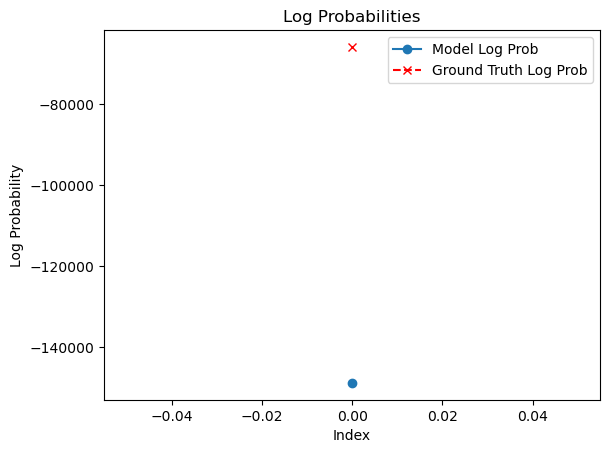

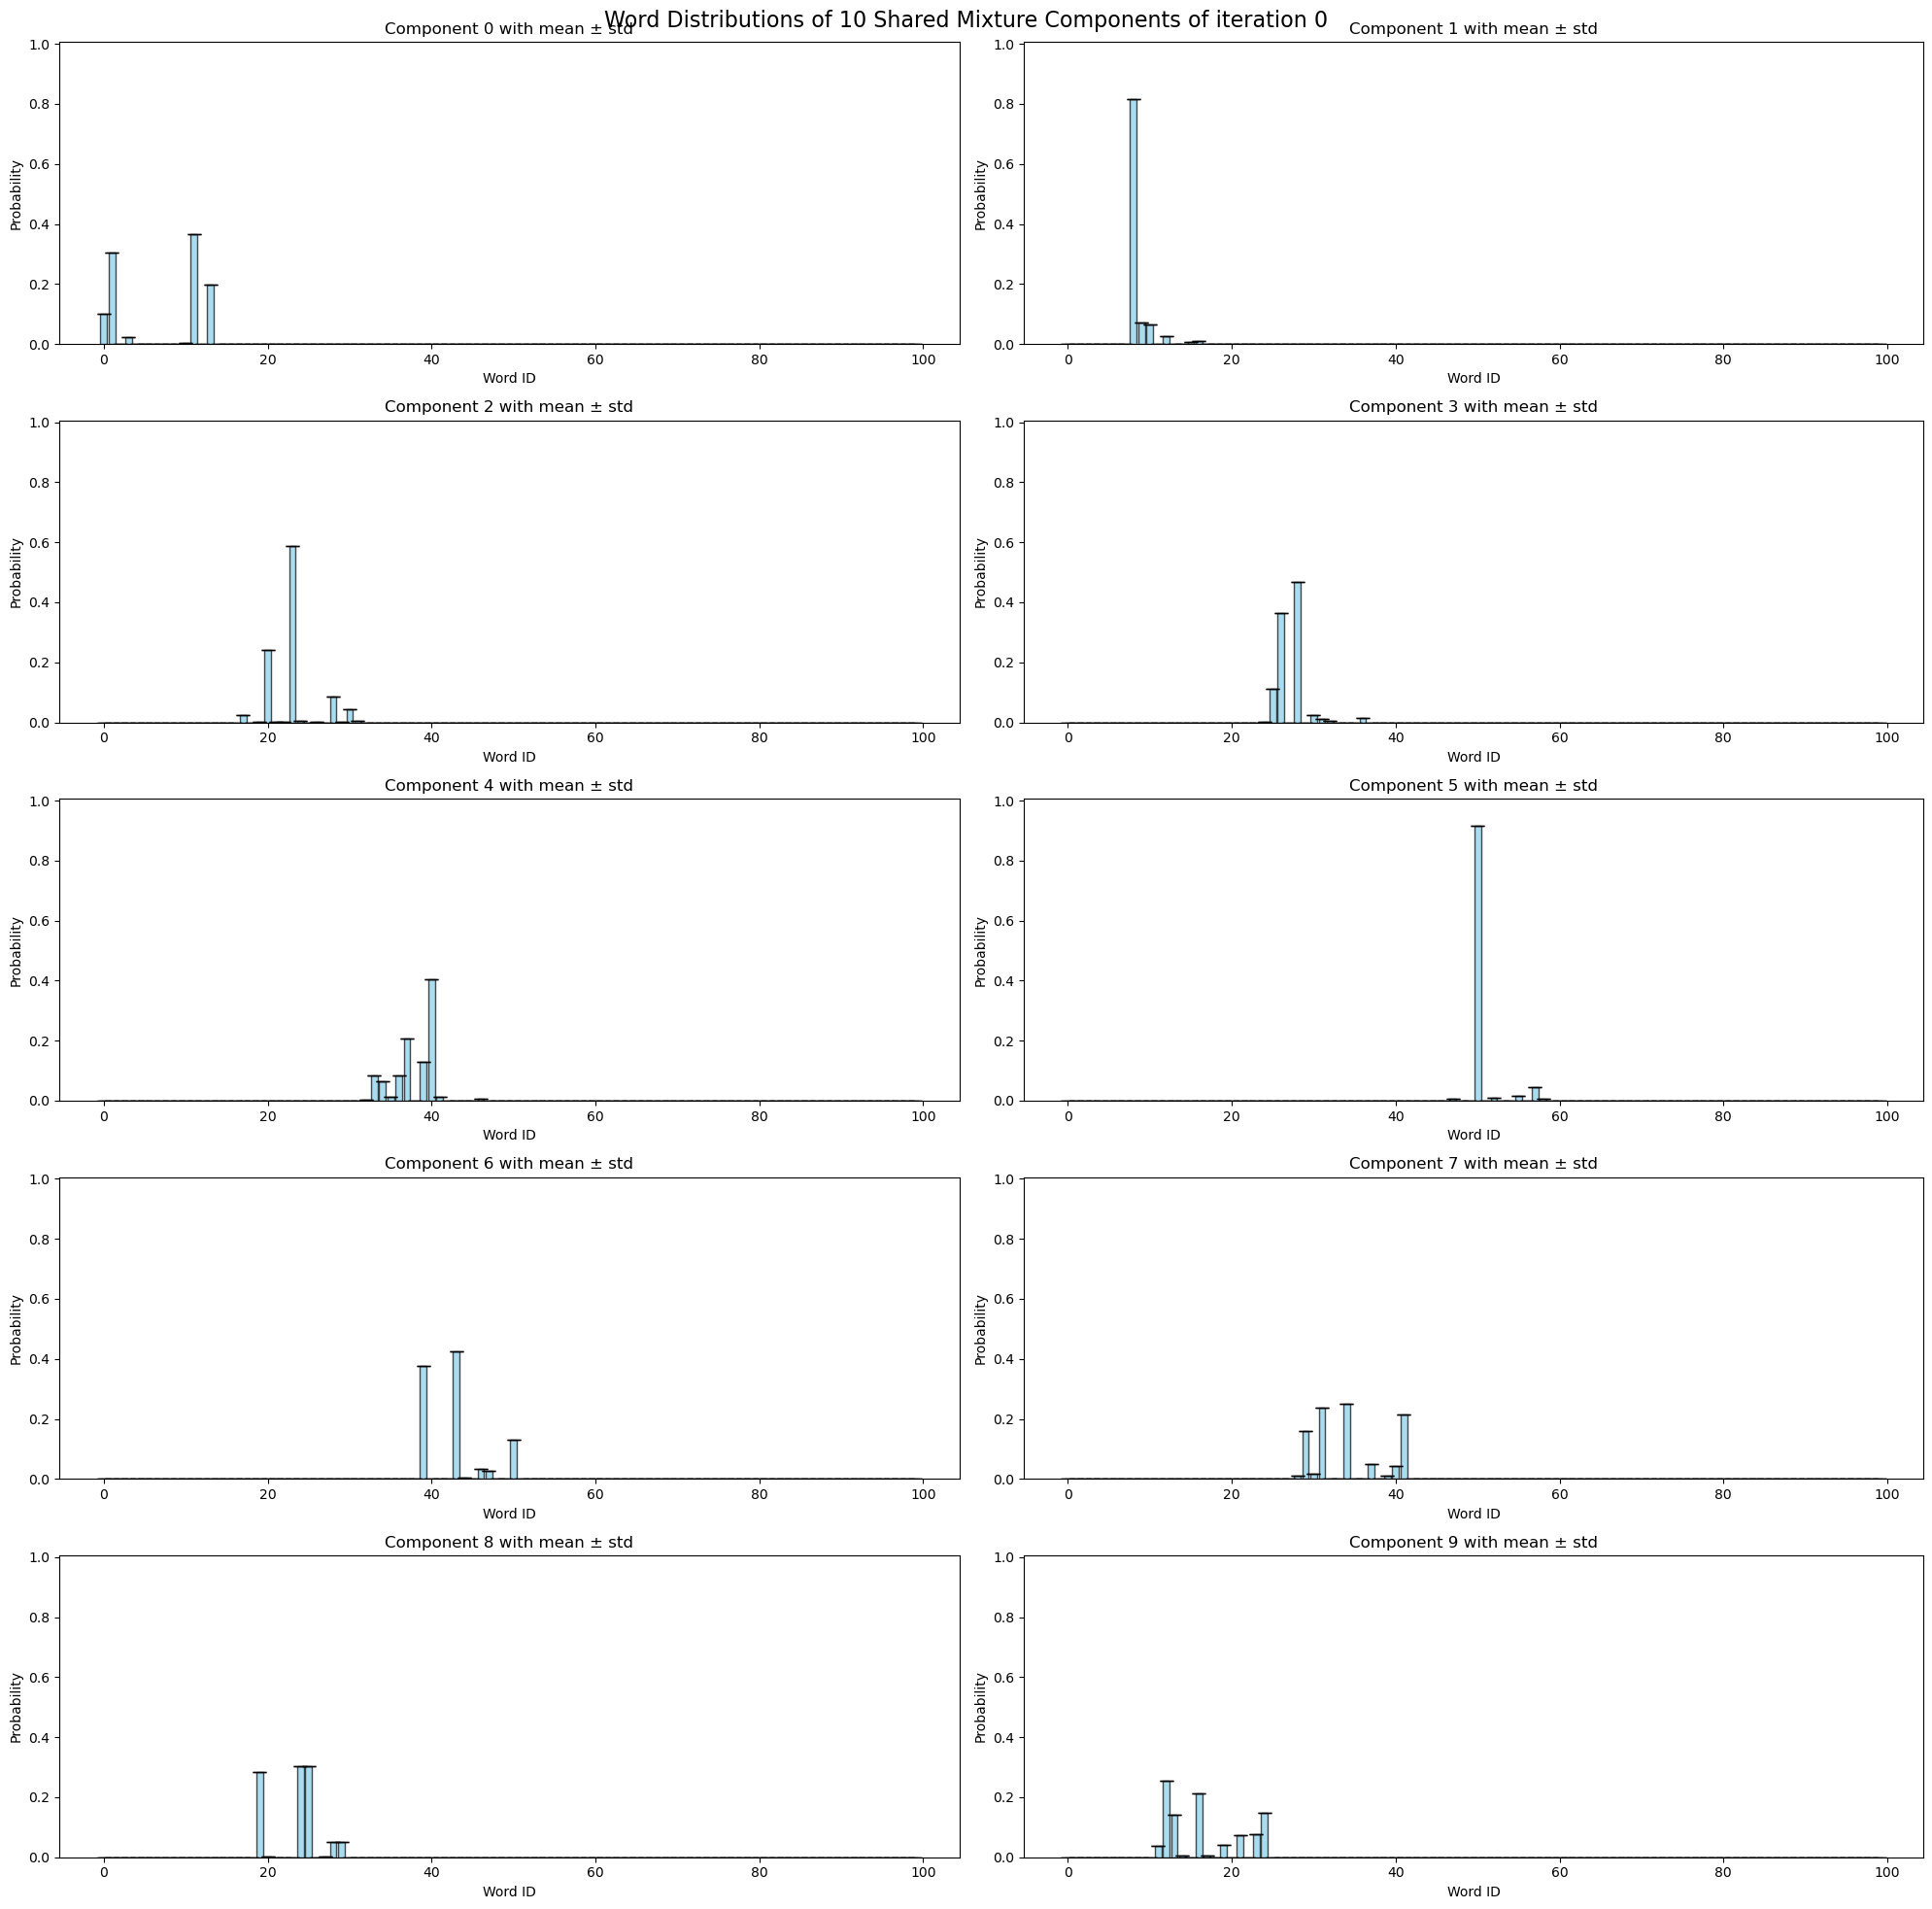

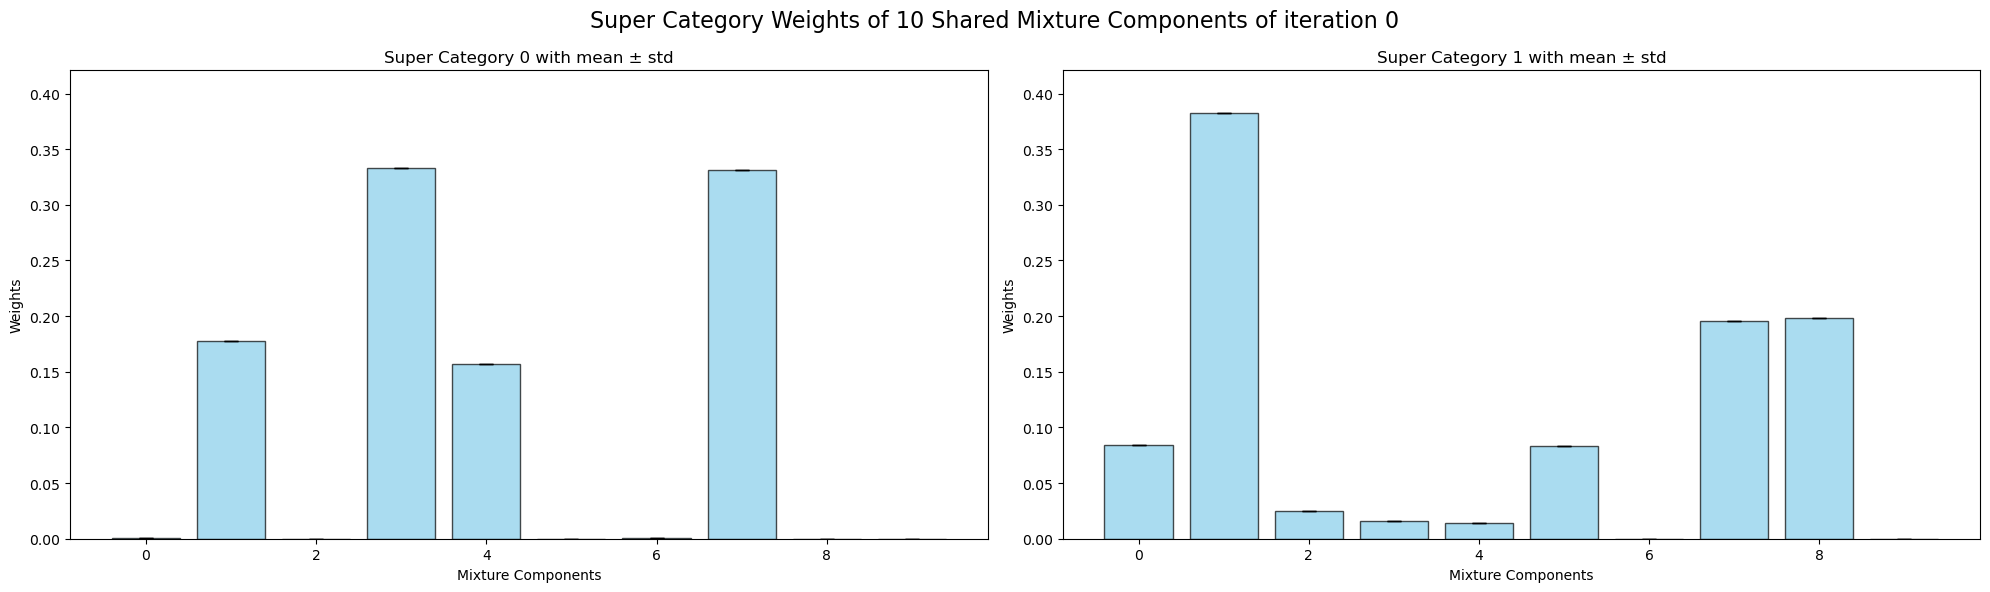

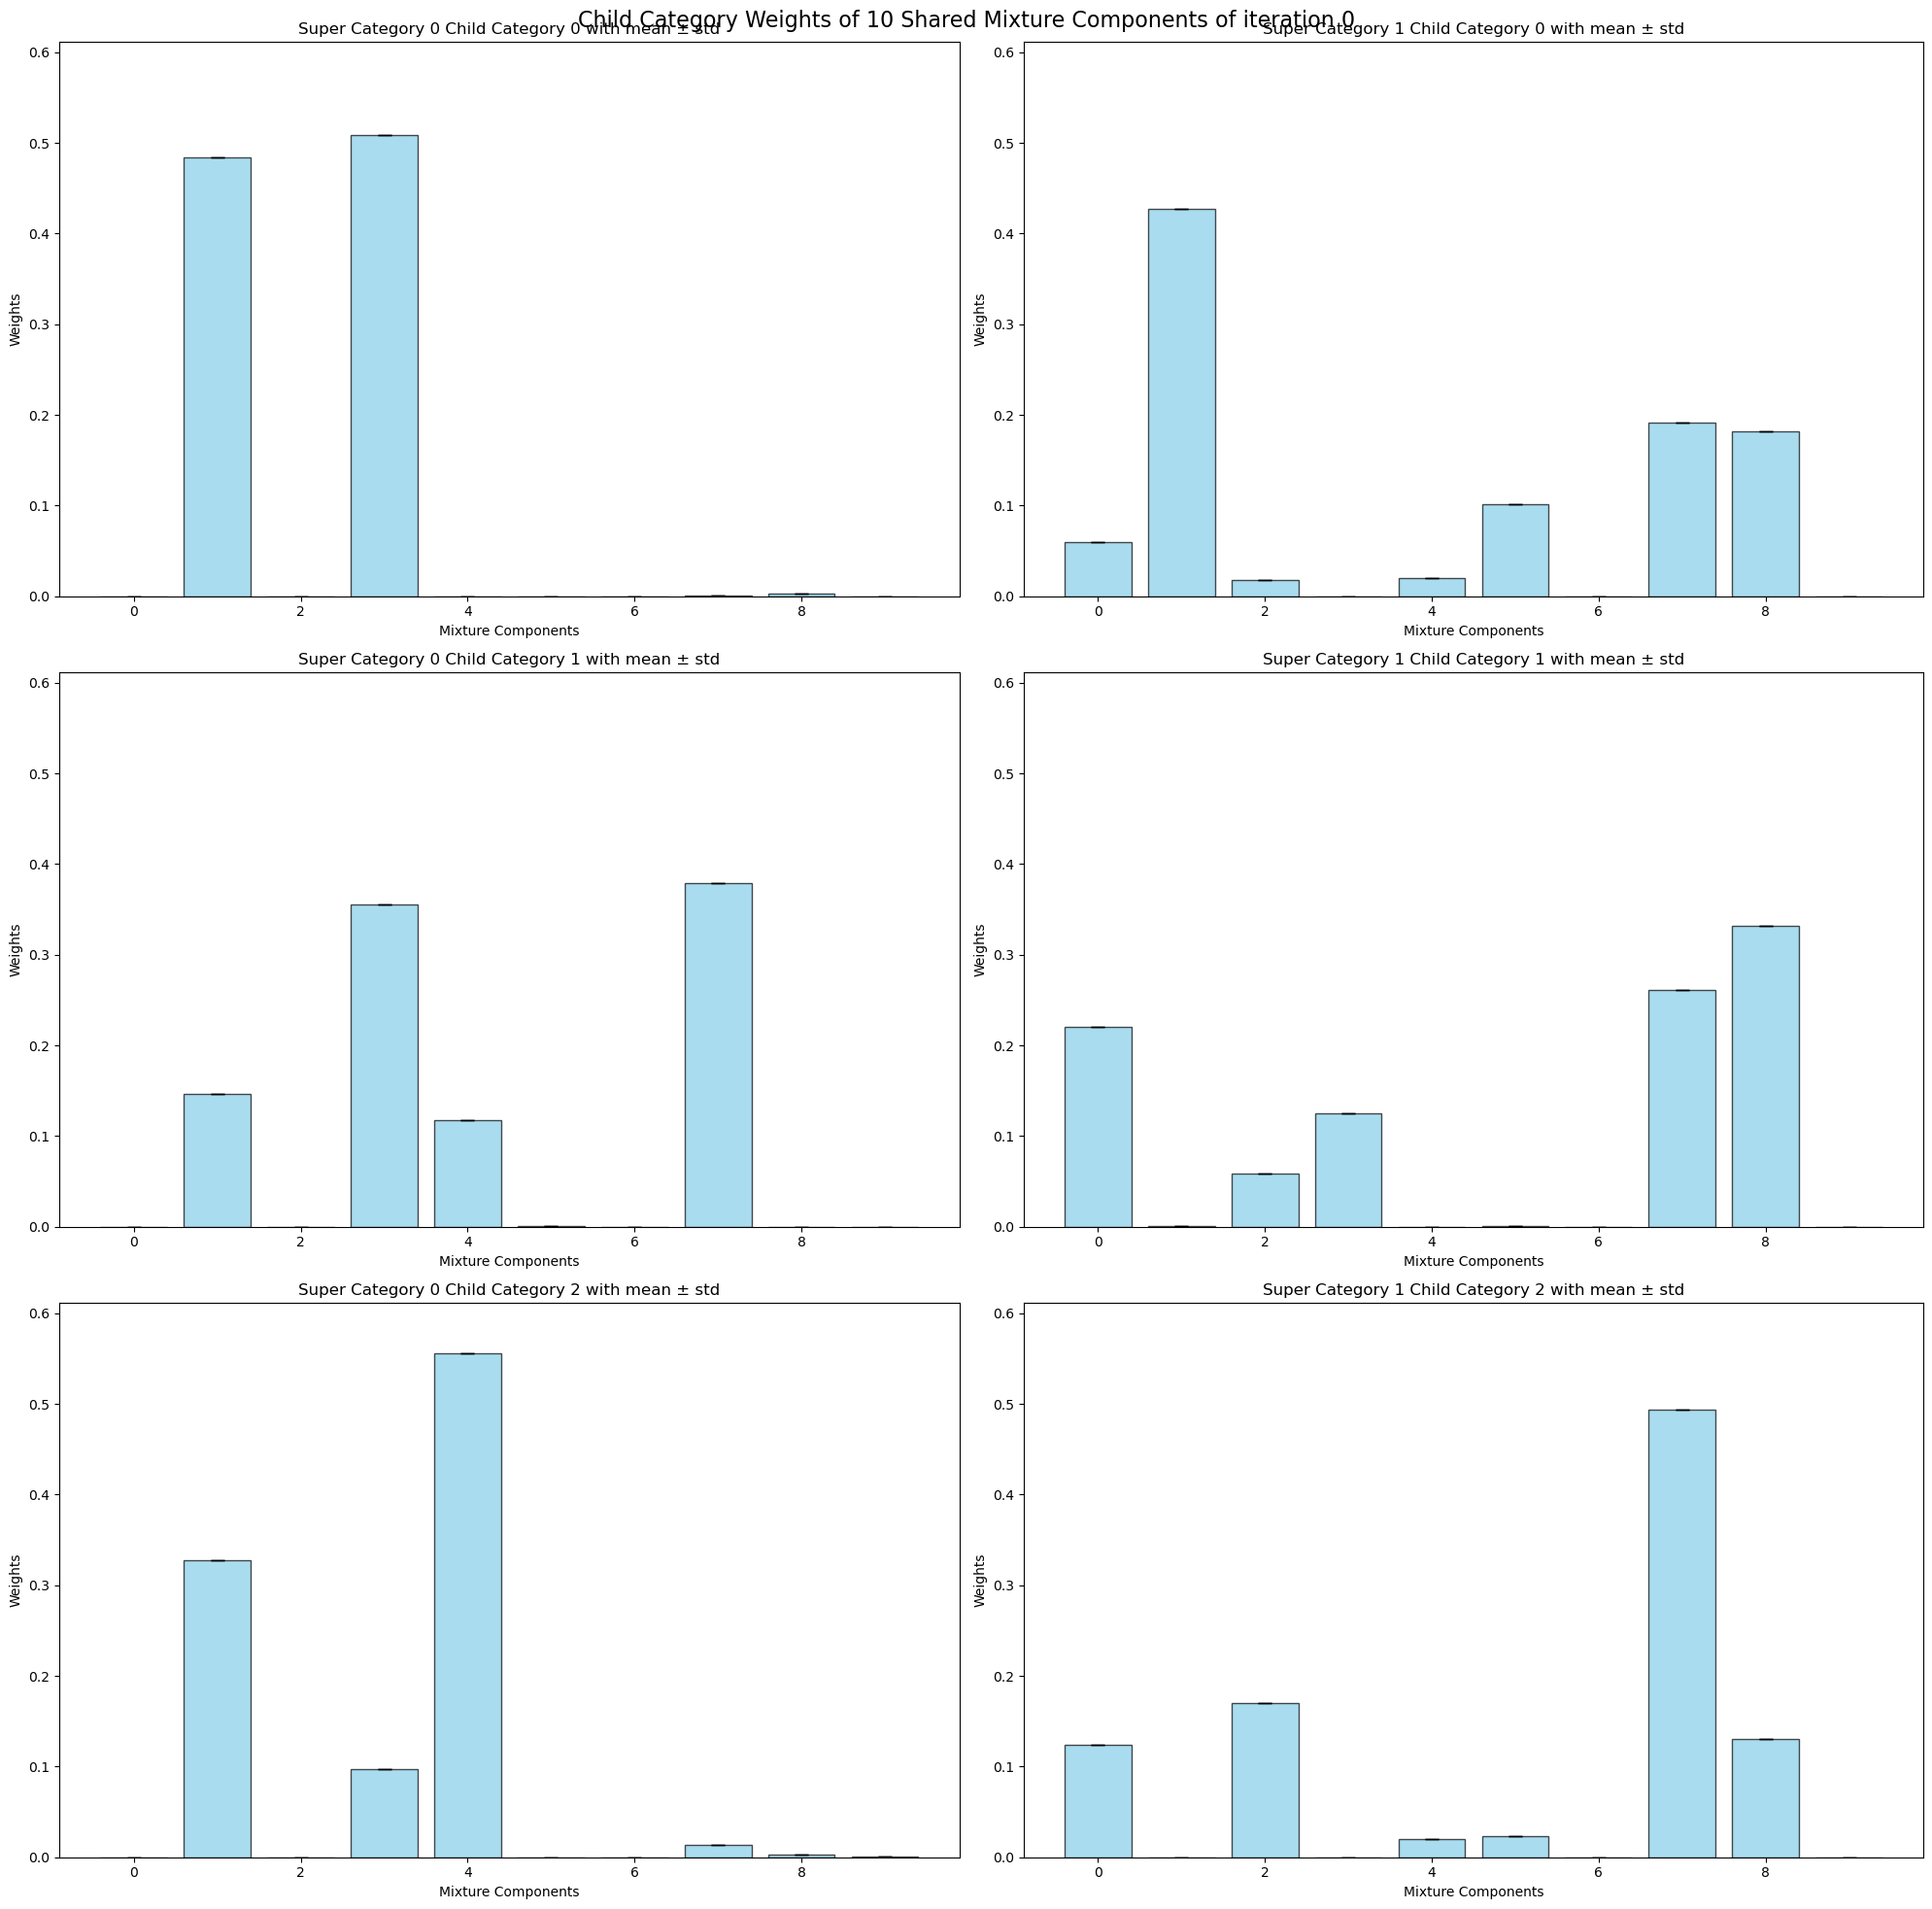

Gibbs Sampling:   2%|▏         | 1/56 [01:21<1:15:06, 81.93s/it]


KeyboardInterrupt: 

In [31]:
dataset = (data["x"], data["y"])
vocab_size = data["x"].shape[-1]
hdmm = model(dataset, struct_upbd=struct_upbd, vocab_size=vocab_size, seed=60, gen_mixture=data["word_dists"], device="cpu")
model_return = gibbs_sampler(jax.random.PRNGKey(0), hdmm, struct_upbd, vocab_size, num_iters=55, gt=data, gen_ground_truth=True)